# Telecom Customer Churn Prediction

**Analisis Komprehensif dan Pemodelan Machine Learning Berbasis Data Telekomunikasi**

## **Pendahuluan**

### **Informasi Umum Proyek**

Proyek ini merupakan inisiatif *predictive analytics* yang berfokus pada perancangan *early warning system* (sistem peringatan dini) untuk mendeteksi probabilitas pelanggan menghentikan layanan (atrisi) pada sebuah entitas bisnis telekomunikasi. Pemodelan klasifikasi biner dibangun menggunakan pendekatan komparatif antara algoritma parametrik konvensional (*Logistic Regression*) dan algoritma *tree-based ensemble* tingkat lanjut (*Random Forest* dan *XGBoost*). Implementasi metrik evaluasi bisnis yang ketat serta interpretasi model (*Explainable AI* melalui *SHAP Analysis*) diterapkan untuk menghasilkan sistem yang tidak hanya memiliki tingkat akurasi tinggi, tetapi juga dapat dipertanggungjawabkan justifikasi statistiknya kepada pemangku kepentingan (*stakeholders*).

### **Informasi Dataset**

Dataset observasional yang digunakan memuat profil pelanggan komprehensif. Atribut prediktor yang dianalisis mencakup tiga dimensi utama operasional bisnis:

1. **Layanan (Services):** Spesifikasi produk yang diaktifkan pelanggan, mencakup ketersediaan layanan telepon, infrastruktur *fiber optic*, *online security*, *device protection*, *tech support*, serta layanan *streaming*.
2. **Akun Finansial (Account Information):** Rekam jejak transaksional yang mencakup durasi waktu berlangganan (*tenure*), jenis kesepakatan kontrak (*contract terms*), metode pembayaran, sistem penagihan, beban *Monthly Charges*, dan akumulasi *Total Charges*.
3. **Demografi (Demographics):** Segmentasi pengguna yang meliputi identitas *gender*, rentang usia (*Senior Citizen* status), kepemilikan pasangan (*Partner*), dan status tanggungan (*Dependents*).

### **Konteks Bisnis Customer Churn**

*Customer Churn* merepresentasikan fenomena kebocoran pendapatan (*revenue leakage*) di mana pelanggan memutus hubungan komersial dengan penyedia layanan. Dalam ekosistem bisnis modern, mitigasi metrik ini menjadi prioritas utama (*top priority*) karena *Customer Acquisition Cost* (CAC) atau biaya untuk mengakuisisi pelanggan baru menuntut pengeluaran kapital yang jauh lebih masif dibandingkan *Customer Retention Cost* (CRC) atau biaya untuk mempertahankan pelanggan yang sudah ada.

Secara matematis, tingkat atrisi (*Churn Rate*) dirumuskan sebagai probabilitas empiris berikut:

$$Churn\ Rate = \left( \frac{C_{L}}{C_{S}} \right) \times 100\%$$

**Keterangan:**
* $C_{L}$ (*Customers Lost*): Kuantitas absolut pelanggan yang membatalkan layanan dalam rentang jendela observasi (*observation window*) tertentu.
* $C_{S}$ (*Customers at Start*): Total populasi basis pelanggan (*customer base*) yang berstatus aktif pada awal rentang observasi.

### **Strategi Retensi Pelanggan (Retention Strategy)**

Penurunan *churn rate* yang signifikan akan berdampak langsung pada optimalisasi *Customer Lifetime Value* (CLV). Hal ini dapat dicapai melalui intervensi strategis berbasis data (*data-driven interventions*), antara lain:

1. Penargetan kampanye retensi yang dipersonalisasi (*personalized retention campaigns*) secara spesifik kepada segmen pelanggan dengan probabilitas *churn* tinggi yang teridentifikasi oleh *Machine Learning*.
2. Restrukturisasi *pricing model* dan penawaran insentif peralihan untuk mendorong pelanggan mengadopsi kontrak berlangganan jangka panjang (*long-term contracts*).
3. Peningkatan kualitas infrastruktur penyediaan layanan dan resolusi komplain (*tech support*) yang lebih responsif untuk meminimalisasi friksi pengalaman pelanggan (*customer friction*).

### **Tujuan Proyek Pemodelan**

Tujuan utama pemodelan adalah mendeploy arsitektur prediktif untuk memisahkan pelanggan ke dalam kelas aman (*Retained*) dan kelas berisiko (*Churned*) berdasarkan pola historis laten. Arsitektur ini diukur objektivitasnya melalui matriks validasi silang (*cross-validation*) untuk mengeliminasi bias evaluasi dalam menentukan algoritma pendeteksi paling optimal bagi perusahaan.

## **Persiapan Lingkungan Kerja (Environment Setup)**

### **Impor Pustaka dan Konfigurasi**

Tahapan inisialisasi lingkungan komputasi berfokus pada pemuatan dependensi (*libraries*) esensial untuk manipulasi bingkai data (*data frame*), operasi matriks aljabar, perenderan visualisasi analitik interaktif, hingga modul fungsional *Machine Learning*.

In [88]:
# Modul pengunduhan dataset / Dataset download module
import kagglehub
import os

# Modul aljabar linier dan manipulasi data / Data manipulation
import pandas as pd
import numpy as np

# Modul visualisasi analitik interaktif (Plotly) dan statis (Matplotlib/Seaborn)
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# Modul data preprocessing, optimasi hyperparameter, dan validasi proporsional
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# Modul metrik evaluasi klasifikasi / Classification evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Algoritma pemodelan prediktif / Predictive modeling architectures
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Modul interpretabilitas prediktif / Explainable AI module
import shap

# Konfigurasi peringatan dan visual dasar / Warnings & plot styling
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

## **Pemanggilan Dataset (Data Ingestion)**

### **Pengunduhan Dataset via Kagglehub**

Tahapan *Data Ingestion* dilakukan secara terprogram menggunakan *Application Programming Interface* (API) untuk menarik *raw data* berformat CSV secara langsung dari repositori *cloud* menuju ruang komputasi lokal.

In [89]:
# Mengunduh arsip dataset versi terbaru / Download the latest dataset build
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Direktori penyimapanan dataset:", path)

# Memindai direktori untuk mengekstrak jalur absolut file / Extract absolute file path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, csv_files[0])

# Mengonversi file CSV menjadi struktur DataFrame / Convert to Pandas DataFrame
df = pd.read_csv(file_path)

# Menampilkan cuplikan lima baris teratas matriks data / Display data snippet
display(df.head())

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Direktori penyimapanan dataset: /kaggle/input/telco-customer-churn


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Berdasarkan hasil pemanggilan awal dan cuplikan data (*dataset preview*) pada tabel di atas, terdapat beberapa indikator awal yang sangat krusial dari perspektif operasional komersial. Berikut adalah wawasan bisnis (*business insights*) strategis yang dapat diekstraksi untuk memitigasi risiko *customer churn*:

1. **Risiko Tinggi pada Fase Awal (*Early Tenure Risk*):** Pelanggan yang melakukan *churn* (Baris 2 dan 4) memiliki durasi berlangganan (*tenure*) yang sangat pendek (hanya 2 bulan). Hal ini mengindikasikan adanya masalah pada fase *onboarding* atau ketidaksesuaian ekspektasi di awal masa langganan, menjadikannya periode paling krusial untuk intervensi tim retensi.

2. **Katalis Kontrak Bulanan (*Month-to-month Contract Catalyst*):** Karakteristik utama dari pelanggan yang *churn* adalah penggunaan jenis kontrak jangka pendek (*Month-to-month*). Fleksibilitas tanpa penalti ini menjadi celah bagi pelanggan untuk dengan mudah beralih ke kompetitor saat menghadapi kendala layanan awal.

3. **Sensitivitas Biaya dan Layanan Premium (*Price & Service Sensitivity*):** Pengguna dengan beban biaya bulanan tinggi (*Monthly Charges* $70.70 pada Baris 4) yang mengadopsi infrastruktur *Fiber Optic* langsung melakukan *churn* dalam tempo singkat. Ini menunjukkan perlunya evaluasi apakah *perceived value* (nilai yang dirasakan pelanggan) dari layanan premium tersebut sudah sebanding dengan biaya yang mereka keluarkan sejak bulan pertama.

## **Preprocessing & Data Cleaning**

### **Pembersihan Dimensi Redundan dan Pengecekan Duplikat**

Fitur referensi identitas (`customerID`) dieliminasi dari observasi. Dalam konteks *predictive modeling*, atribut identifikasi unik bertindak sebagai *noise* karena tidak memberikan *predictive power* yang dapat digeneralisasi oleh algoritma. Pengecekan integritas (*data integrity*) terkait duplikasi baris (*duplicate rows*) juga dilakukan untuk mencegah bias frekuensi.

In [90]:
# Mengeliminasi dimensi fitur yang tidak relevan / Drop non-predictive feature
df.drop('customerID', axis=1, inplace=True)

# Kalkulasi agregat keberadaan matriks baris ganda / Check duplicate entries
jumlah_duplikat = df.duplicated().sum()
print(f"Total observasi duplikat terdeteksi: {jumlah_duplikat}")

# Prosedur reduksi baris ganda / Drop duplicates if any
if jumlah_duplikat > 0:
    df.drop_duplicates(inplace=True)
    print("Seluruh observasi duplikat berhasil direduksi dari populasi data.")

Total observasi duplikat terdeteksi: 22
Seluruh observasi duplikat berhasil direduksi dari populasi data.


Berdasarkan hasil tahapan *data cleaning* yang mendeteksi dan mereduksi 22 baris observasi duplikat, terdapat implikasi krusial terhadap integritas data operasional dan validitas pemodelan prediktif. Berikut adalah wawasan bisnis (*business insights*) singkat terkait temuan tersebut:

1. **Akurasi Metrik Finansial dan Operasional (*Financial and Operational Metric Accuracy*):** Penghapusan observasi duplikat ini mengeliminasi risiko pencatatan ganda (*double counting*) pada variabel finansial seperti *Monthly Charges* dan *Total Charges*. Hal ini memastikan bahwa analisis arus kas (*revenue stream*) dan kalkulasi *churn rate* perusahaan merepresentasikan jumlah unit pelanggan unik secara presisi, sehingga mencegah kesalahan estimasi kerugian finansial.

2. **Peningkatan Keandalan Model Prediktif (*Predictive Model Reliability*):** Keberadaan data duplikat berpotensi memicu *overfitting* atau *data leakage*, di mana algoritma secara buatan memberikan bobot berlebih pada profil pelanggan tertentu yang berulang. Reduksi data duplikat ini menjamin bahwa model *Machine Learning* mempelajari pola perilaku atrisi secara objektif, sehingga meningkatkan kemampuan generalisasi model saat diimplementasikan pada data baru di masa mendatang (*unseen data*).

### **Audit dan Identifikasi Missing Values**

Dalam operasional basis data riil, elemen yang hilang (*missing values*) tidak selalu terdaftar sebagai nilai `NaN` (Not a Number) standar sistem. Anomali representasi seperti karakter *whitespace* (spasi kosong) dikonversi menjadi standar numerik sebelum menghitung defisiensi data populasi.

Formula Persentase Missing Values ($PMV$):

$$PMV = \left( \frac{N_{miss}}{N_{total}} \right) \times 100\%$$

**Keterangan:**
* $PMV$: Rasio persentase hilangnya titik data (*data points*) pada suatu atribut fitur.
* $N_{miss}$: Kuantitas absolut observasi kosong (jumlah cacat data).
* $N_{total}$: Kapasitas dimensi panjang total dari fitur observasi.

In [92]:
# Transformasi karakter spasi kosong menjadi representasi standar / Convert spaces to NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Konversi vektor string menjadi tipe floating-point numerik / Type casting to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Kalkulasi distribusi kuantitatif dan persentase / Calculate missingness proportions
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

# Rekonstruksi informasi ke dalam matriks audit / Audit mapping
df_missing = pd.DataFrame({
    'Kuantitas Missing Values': missing_data,
    'Persentase Proporsi (%)': missing_percentage
})

# Filter fitur yang terindikasi memiliki nilai defisit / Filter deficient features
df_missing_filtered = df_missing[df_missing['Kuantitas Missing Values'] > 0]

print("=== Laporan Audit Missing Values ===")
display(df_missing_filtered)

=== Laporan Audit Missing Values ===


,Kuantitas Missing Values,Persentase Proporsi (%)
TotalCharges,11,0.156673


Berdasarkan hasil laporan audit *missing values* pada tabel di atas, teridentifikasi 11 data tak terdefinisi pada atribut `TotalCharges` dengan proporsi yang sangat kecil (0.16%). Kendati kuantitasnya minim, temuan ini memberikan refleksi penting terkait fase awal *customer lifecycle*, dengan rincian wawasan bisnis (*business insights*) sebagai berikut:

* **Identifikasi Segmen Pelanggan Baru (*New Customer Cohort*):** Secara operasional, hilangnya data pada komponen *Total Charges* terjadi secara eksklusif pada pelanggan dengan durasi langganan (*tenure*) sebesar nol bulan. Hal ini menunjukkan bahwa data yang hilang tersebut merepresentasikan pelanggan yang baru saja diakuisisi (*newly acquired customers*) dan belum menyelesaikan siklus penagihan pertama (*first billing cycle*).

* **Perlindungan Data dari Bias Efek (*Data Integrity Protection*):** Mengingat persentase kelangkaan data ini sangat rendah (0.16%), keputusan untuk tidak membuang baris data melainkan menggunakan *KNN Imputation* merupakan langkah mitigasi risiko yang tepat. Langkah ini memastikan model tetap dapat mempelajari karakteristik profil dari klaster pelanggan baru tanpa merusak distribusi varians finansial, mengingat kelompok *early tenure* secara historis memiliki kerentanan yang tinggi terhadap *early churn*.

### **Analisis Mekanisme Missing Values**

Investigasi teoretis atas *missing values* pada `TotalCharges` dikategorikan berdasarkan taksonomi probabilitas inferensial:

1. **MCAR (*Missing Completely at Random*):** Absennya titik data independen tanpa pola yang mendasarinya.
2. **MAR (*Missing at Random*):** Absennya titik data memiliki ketergantungan statistik kondisional terhadap atribut variabel lain.
3. **MNAR (*Missing Not at Random*):** Absennya titik data bergantung pada nilai intrinsik dari data yang hilang itu sendiri.

Observasi mengindikasikan bahwa defisit pada `TotalCharges` terjadi secara deterministik khusus pada pelanggan baru di mana `tenure` (durasi langganan) tepat bernilai $0$. Karena dipengaruhi secara kondisional oleh observasi fitur lain, mekanisme diklasifikasikan sebagai **MAR (*Missing at Random*)**.

### **Imputasi Jarak dengan K-Nearest Neighbors (KNN Imputation)**

Pendekatan algoritmik *KNN Imputation* digunakan untuk mengestimasi proksi nilai hilang (*missing values*) dengan merujuk pada profil fitur tetangga berkarakteristik mirip. Pendekatan spasial ini lebih tangguh mengamankan varians distribusi dibandingkan imputasi univariat statis (seperti *Mean* atau *Median*).

Formula Metrik Jarak Euclidean (*Euclidean Distance Metric*):

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

**Keterangan:**
* $d(x, y)$: Magnitudo jarak linear ruang fitur antara titik pengamatan pelanggan $x$ dan $y$.
* $n$: Total atribut prediktor kuantitatif yang digunakan dalam pembobotan matriks.
* $x_i, y_i$: Skalar nilai fitur ke-$i$ pada titik vektor yang diukur.

In [5]:
# Transformasi label respons target menjadi tipe biner standar industri / Target binary encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Pemisahan ruang numerik untuk komputasi jarak algoritmik / Isolate numeric spaces
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_numerik = df[numeric_cols]

# Konfigurasi inisial estimator KNN dengan parameter k=5 / Init KNN Imputer
imputer = KNNImputer(n_neighbors=5, weights="uniform")

# Proses fiting dan substitusi skalar menuju DataFrame / Compute and substitute
df[numeric_cols] = imputer.fit_transform(df_numerik)

print("Validasi Defisiensi Data Pasca-Imputasi KNN:")
print(df[numeric_cols].isnull().sum())

Validasi Defisiensi Data Pasca-Imputasi KNN:
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


Berdasarkan hasil validasi defisiensi data pasca-imputasi menggunakan teknik *K-Nearest Neighbors* (KNN) pada tabel di atas, seluruh nilai yang hilang (*missing values*) pada komponen numerik telah berhasil dipulihkan sepenuhnya menjadi nol. Berikut adalah wawasan bisnis (*business insights*) singkat terkait signifikansi tahapan tersebut terhadap keandalan sistem prediksi:

* **Kesiapan Mutlak Matriks Pemodelan (*Model Readiness and Data Completeness*):** Pencapaian status bebas nilai hilang (*zero missing values*) ini memastikan bahwa matriks fitur (*feature matrix*) kini berada dalam kondisi komplit 100%. Kelengkapan data ini sangat krusial bagi algoritma parametrik seperti *Logistic Regression* yang tidak toleran terhadap nilai kosong, sehingga menjamin stabilitas komputasi dan mencegah kegagalan matematis pada fase *model training*.

* **Retensi Informasi Klaster Pelanggan Baru (*Preservation of New Cohort Variances*):** Dengan memanfaatkan kedekatan spasial KNN untuk mengestimasi nilai `TotalCharges` yang kosong, karakteristik finansial dari segmen pelanggan berdurasi langganan nol bulan (*early tenure cohort*) tetap dapat dipertahankan di dalam dataset tanpa memicu bias rata-rata. Hal ini sangat penting bagi strategi bisnis karena kelompok pelanggan baru secara historis memiliki sensitivitas dan risiko tinggi terhadap gejala *early churn*.

## **Pendeteksian Pencilan (Outlier Detection)**

### **Analisis Pencilan pada Variabel Kontinu**

Pendeteksian nilai ekstrem atau *outliers* yang dapat mendistorsi fungsi kerugian algoritma pemodelan diukur melalui batasan sebaran kuartil (*Interquartile Range* / IQR).

Formula Batasan Kuartil Matematis (*IQR Bounds*):

$$IQR = Q_3 - Q_1$$

$$Batas\ Bawah = Q_1 - 1.5 \times IQR$$

$$Batas\ Atas = Q_3 + 1.5 \times IQR$$

**Keterangan:**
* $Q_1$: Batas kuartil pertama (*25th percentile* dari sebaran distribusi).
* $Q_3$: Batas kuartil ketiga (*75th percentile* dari sebaran distribusi).
* $1.5$: Pengali konstan untuk mengukur ambang batas variasi normal non-parametrik.

In [95]:
# Definisi fungsi ekstraksi pencilan berbasis kuartil / IQR function definition
def hitung_outliers_iqr(dataframe, kolom):
    Q1 = dataframe[kolom].quantile(0.25)
    Q3 = dataframe[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[kolom] < batas_bawah) | (dataframe[kolom] > batas_atas)]
    return len(outliers)

# Pencatatan ringkasan matriks pencilan / Logging outlier metrics
outlier_data = []
for col in numeric_cols:
    jml_outlier = hitung_outliers_iqr(df, col)
    persentase = (jml_outlier / len(df)) * 100
    outlier_data.append([col, jml_outlier, f"{persentase:.2f}%"])

df_outliers = pd.DataFrame(outlier_data, columns=['Atribut Numerik', 'Kuantitas Outlier', 'Rasio Terhadap Populasi'])
print("=== Tabel Audit Distribusi Outlier ===")
display(df_outliers)

=== Tabel Audit Distribusi Outlier ===


,Atribut Numerik,Kuantitas Outlier,Rasio Terhadap Populasi
0,tenure,0,0.00%
1,MonthlyCharges,0,0.00%
2,TotalCharges,0,0.00%


Berdasarkan laporan audit distribusi pencilan (*outlier distribution audit*) pada tabel di atas, konfirmasi menunjukkan bahwa tidak ditemukan satu pun data ekstrem (0.00% *outlier ratio*) pada ketiga dimensi numerik kontinu tersebut. Berikut adalah wawasan bisnis (*business insights*) singkat terkait implikasi kebersihan distribusi data terhadap operasional komersial dan stabilitas sistem prediksi atrisi:

* **Konsistensi Struktur Tarif dan Paket Layanan (*Billing and Tariff Consistency*):** Ketiadaan data ekstrem pada komponen *Monthly Charges* dan *Total Charges* mencerminkan bahwa sistem penagihan (*billing system*) operasional berjalan secara terstruktur dalam koridor skema harga (*pricing scheme*) yang baku. Hal ini mengonfirmasi integritas data transaksional perusahaan yang bersih dari kesalahan input manual (*clerical errors*) ataupun anomali penagihan yang tidak realistis di luar batas wajar paket komersial.

* **Stabilitas Estimasi Batas Keputusan Model (*Algorithmic Decision Boundary Stability*):** Kondisi data kontinu yang bersih dari pencilan ini sangat menguntungkan bagi optimalisasi performa algoritma prediktif, khususnya model parametrik seperti *Logistic Regression*. Tanpa adanya pencilan, estimasi koefisien pembobot variabel finansial tidak akan terdistorsi oleh nilai ekstrem, sehingga memastikan kurva batas keputusan (*decision boundary*) yang terbentuk memiliki kapabilitas generalisasi (*generalization capability*) yang tinggi saat memetakan risiko *churn* pelanggan.

In [96]:
# Boxplot untuk Tenure
fig_box_tenure = px.box(df, y='tenure', title='Inspeksi Pencilan: Tenure (Durasi Berlangganan)', points='outliers')
fig_box_tenure.update_traces(marker_color='#1f77b4')
fig_box_tenure.update_layout(xaxis_title='', yaxis_title='Bulan', height=400, width=600)
fig_box_tenure.show()

Berdasarkan hasil visualisasi inspeksi pencilan untuk variabel `tenure` (durasi berlangganan) pada grafik di atas, sebaran data menunjukkan pola operasional komersial yang stabil tanpa adanya distorsi ekstrem. Berikut adalah wawasan bisnis (*business insights*) singkat terkait karakteristik durasi berlangganan pelanggan:

* **Distribusi Siklus Hidup Pelanggan yang Luas (*Wide Customer Lifecycle Distribution*):** Rentang kotak *Interquartile Range* (IQR) menunjukkan bahwa 50% basis pelanggan utama perusahaan terkonsentrasi pada masa berlangganan antara kisaran 9 hingga 55 bulan, dengan nilai median bertengger di sekitar 29 bulan. Sebaran yang merata ini mencerminkan portfolio pelanggan yang matang dan bervariasi melintasi berbagai tahapan loyalitas.

* **Ketiadaan Anomali Operasional Kontrak (*Absence of Operational Anomalies*):** Konfirmasi visual menunjukkan tidak adanya titik pencilan (*outliers*) baik di bawah batas minimum (0 bulan) maupun di atas batas maksimum (sekitar 72 bulan). Hal ini membuktikan tingkat keandalan data yang tinggi (*high data integrity*), bersih dari kesalahan input (*data entry errors*), serta menegaskan bahwa batas atas masa langganan pelanggan terkunci secara logis pada batas wajar operasional bisnis telekomunikasi (sekitar 6 tahun).

In [97]:
# Boxplot untuk MonthlyCharges
fig_box_monthly = px.box(df, y='MonthlyCharges', title='Inspeksi Pencilan: Monthly Charges', points='outliers')
fig_box_monthly.update_traces(marker_color='#2ca02c')
fig_box_monthly.update_layout(xaxis_title='', yaxis_title='USD', height=400, width=600)
fig_box_monthly.show()

Berdasarkan hasil visualisasi inspeksi pencilan untuk variabel `MonthlyCharges` (beban biaya bulanan) pada grafik di atas, sebaran data menunjukkan profil finansial pelanggan yang bervariasi namun tetap berada dalam batas komersial yang terstruktur. Berikut adalah wawasan bisnis (*business insights*) singkat terkait karakteristik beban tagihan bulanan tersebut:

* **Konsentrasi Segmen Menengah ke Atas (*High-Value Segment Concentration*):** Rentang kotak *Interquartile Range* (IQR) mengonfirmasi bahwa 50% basis pelanggan utama memberikan kontribusi pendapatan bulanan antara kisaran 35 USD hingga 90 USD, dengan nilai median berada di sekitar 70 USD. Tingginya konsentrasi pelanggan pada segmen menengah ke atas ini memerlukan perhatian khusus dari manajemen, sebab kelompok pengguna dengan pengeluaran tinggi umumnya memiliki ekspektasi kualitas yang ketat dan sangat sensitif terhadap keselarasan harga dengan nilai layanan (*price-to-service value alignment*).

* **Akurasi Batas Tarif Paket Komersial (*Valid Tariff Pricing Tiers*):** Ketiadaan titik pencilan (*outliers*) baik di bawah batas minimum (18 USD) maupun di atas batas maksimum (120 USD) membuktikan bahwa seluruh rekaman transaksional bersih dari galat penagihan (*billing system errors*). Rentang ini secara logis mencerminkan variasi paket produk resmi perusahaan—mulai dari paket dasar (*basic phone service*) hingga paket premium berbiaya tinggi (*fiber optic bundles*)—sehingga batas keputusan (*decision boundary*) model dalam memprediksi *churn* akan terbentuk berdasarkan pola struktur harga riil yang valid.

In [98]:
# Boxplot untuk TotalCharges
fig_box_total = px.box(df, y='TotalCharges', title='Inspeksi Pencilan: Total Charges', points='outliers')
fig_box_total.update_traces(marker_color='#17becf')
fig_box_total.update_layout(xaxis_title='', yaxis_title='USD', height=400, width=600)
fig_box_total.show()

Berdasarkan hasil visualisasi inspeksi pencilan untuk variabel `TotalCharges` (akumulasi tagihan total) pada grafik di atas, sebaran data menunjukkan pola akumulasi nilai transaksi jangka panjang yang asimetris namun tetap bersih dari distorsi ekstrem. Berikut adalah wawasan bisnis (*business insights*) singkat terkait karakteristik nilai finansial kumulatif tersebut:

* **Asimetri Kontribusi dan Potensi Nilai Hidup Pelanggan (*Asymmetrical Customer Lifetime Value*):** Posisi garis median yang cenderung berada di paruh bawah kotak (sekitar 1.400 USD) menandakan bahwa sebagian besar basis pelanggan utama di dalam data memiliki akumulasi pengeluaran yang relatif rendah, yang umumnya diisi oleh kelompok pelanggan baru (*early tenure*) atau pengguna paket hemat. Sebaliknya, rentang kumis atas (*upper whisker*) yang memanjang sangat jauh hingga menembus kisaran 8.000 USD merepresentasikan kelompok pelanggan setia bernilai tinggi (*high-value loyal segment*). Retensi terhadap segmen kuartil atas ini menjadi prioritas bisnis paling kritikal karena dampak finansial akibat kehilangan satu pelanggan premium ini setara dengan kehilangan banyak pelanggan reguler.

* **Validitas Logis Akumulasi Finansial (*Mathematical Consistency of Billing Data*):** Konfirmasi visual menunjukkan tidak adanya titik pencilan (*outliers*) murni di luar batas *whisker*. Karakteristik tanpa pencilan ini mengonfirmasi *data integrity* yang sangat tinggi, di mana angka tagihan tertinggi (sekitar 8.600 USD) terbukti konsisten secara matematis sebagai hasil perkalian logis antara pelanggan paket premium tertinggi (pada limitasi 120 USD/bulan) yang telah bertahan hingga masa kontrak maksimum (120 USD $\times$ 72 bulan = 8.640 USD). Distribusi finansial kontinu yang valid ini akan menjaga stabilitas model *Machine Learning* dalam memetakan batas keputusan klasifikasi risiko atrisi tanpa terganggu oleh anomali data transaksional.

## **Exploratory Data Analysis (EDA)**

### **Statistik Deskriptif (Descriptive Statistics)**

Representasi statistik merangkum *central tendency* dan tingkat dispersi data populasi secara holistik untuk memberikan gambaran wawasan dasar.

Formula Ekspektasi Rata-rata (*Mean*) dan Simpangan Baku (*Standard Deviation*):

$$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i \quad ; \quad \sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}$$

**Keterangan:**
* $\mu$: Vektor nilai rata-rata dari populasi pengamatan.
* $\sigma$: Pengukuran dispersi data (*spread*) dari varians akar kuadrat.
* $N$: Basis total dari unit entitas pengamatan pelanggan.
* $x_i$: Skalar nilai kuantitatif pada pengamatan ke-$i$.

In [101]:
# Ekstraksi matriks tendensi sentral untuk dimensi kuantitatif / Numeric central tendency
print("=== Statistik Deskriptif Atribut Numerik ===")
display(df[numeric_cols].describe().round(2))

=== Statistik Deskriptif Atribut Numerik ===


,tenure,MonthlyCharges,TotalCharges
count,7021.00,7021.00,7010.00
mean,32.47,64.85,2290.35
std,24.53,30.07,2266.82
min,0.00,18.25,18.80
25%,9.00,35.75,408.31
50%,29.00,70.40,1403.88
75%,55.00,89.90,3807.84
max,72.00,118.75,8684.80


Berdasarkan rangkuman statistik deskriptif dari atribut numerik pada tabel di atas, terdapat beberapa karakteristik hubungan komersial dari pangkalan pelanggan (*customer base*) yang merefleksikan pola konsumsi serta risiko pendapatan perusahaan. Berikut adalah wawasan bisnis (*business insights*) strategis yang dapat diekstraksi:

* **Periode Kritis Kemitraan Pelanggan (*Early Attrition Window*):** Rata-rata durasi berlangganan pelanggan (*mean tenure*) berada di angka 32,47 bulan, namun memiliki variabilitas yang tinggi dengan standar deviasi mencapai 24,53 bulan. Mengingat 25% pelanggan pertama (*25th percentile*) memiliki masa langganan 9 bulan atau kurang, perusahaan menghadapi risiko *early churn* yang masif pada fase awal. Manajemen perlu memperkuat strategi *onboarding engagement* dan merancang program loyalitas proaktif sebelum jendela kritis 9 bulan tersebut terlampaui.

* **Konsentrasi Pendapatan pada Segmen Premium (*High-ARPU Revenue Risk*):** Nilai median untuk *Monthly Charges* (70,40 USD) terpantau lebih tinggi dibandingkan nilai rata-ratanya (64,85 USD), yang menandakan bahwa distribusi data didominasi oleh paket layanan berbiaya tinggi. Karena sebagian besar pelanggan berada di rentang tagihan bulanan 70,40 USD hingga 118,75 USD, kontribusi ARPU (*Average Revenue Per User*) terbesar datang dari segmen ini. Proteksi terhadap klaster ini sangat krusial karena setiap kejadian *churn* di segmen premium akan mendistorsi profitabilitas bulanan secara signifikan.

* **Polarisasi Nilai Hidup Pelanggan (*Customer Lifetime Value Polarization*):** Atribut *Total Charges* menunjukkan dispersi data yang sangat lebar dengan standar deviasi (2.266,82 USD) yang hampir setara dengan nilai rata-ratanya (2.290,35 USD), serta nilai maksimum yang menyentuh 8.684,80 USD. Hal ini mencerminkan adanya polarisasi nyata antara pelanggan jangka pendek dan pelanggan loyal jangka panjang. Mempertahankan kelompok kuartil atas (*75th percentile* ke atas dengan akumulasi pengeluaran > 3.807,84 USD) merupakan agenda wajib tim retensi untuk melindungi kapabilitas *Customer Lifetime Value* (CLV) kumulatif perusahaan.

In [103]:
# Ekstraksi matriks proporsi untuk dimensi nominal kategorikal / Categorical frequency mapping
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("=== Statistik Deskriptif Atribut Kategorikal ===")
display(df[categorical_cols].describe().T)

=== Statistik Deskriptif Atribut Kategorikal ===


,count,unique,top,freq
gender,7021,2,Male,3541
Partner,7021,2,No,3619
Dependents,7021,2,No,4911
PhoneService,7021,2,Yes,6339
MultipleLines,7021,3,No,3368
InternetService,7021,3,Fiber optic,3090
OnlineSecurity,7021,3,No,3490
OnlineBackup,7021,3,No,3080
DeviceProtection,7021,3,No,3087
TechSupport,7021,3,No,3465


Berdasarkan rangkuman statistik deskriptif untuk atribut kategorikal pada tabel di atas, karakteristik operasional dan profil portofolio pelanggan menunjukkan beberapa pola perilaku dominan yang berkorelasi langsung dengan stabilitas pendapatan perusahaan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi dari dominasi kategori tersebut:

* **Kerentanan Struktural Jenis Kontrak (*Contract Structural Vulnerability*):** Variabel `Contract` didominasi oleh tipe *Month-to-month* dengan frekuensi mencapai 3.853 pengamatan (sekitar 55% dari total basis pelanggan). Dominasi kontrak jangka pendek ini merefleksikan tingkat fleksibilitas transaksional (*transactional flexibility*) yang sangat tinggi bagi pelanggan. Hal ini menjadi pemicu utama tingginya risiko atrisi karena tidak adanya hambatan finansial (*switching cost*) atau penalti yang mengikat pelanggan untuk bertahan.

* **Kesenjangan Penetrasi Layanan Tambahan (*Value-Added Services Penetration Gap*):** Walaupun infrastruktur internet premium (`InternetService`) berbasis *Fiber optic* menjadi kategori yang cukup dominan (3.090 pelanggan), mayoritas pelanggan justru tercatat tidak mengaktifkan fitur proteksi krusial seperti `OnlineSecurity` (3.490 berstatus "No") dan `TechSupport` (3.465 berstatus "No"). Kesenjangan ini mengindikasikan adanya peluang kemitraan produk (*cross-selling opportunities*) yang belum tergarap optimal; mengunci pengguna *Fiber optic* dengan bundel layanan keamanan dan dukungan teknis dapat meningkatkan *perceived value* sekaligus mereduksi risiko perpindahan pelanggan akibat kendala jaringan.

* **Risiko Friksi pada Saluran Transaksi (*Payment Method Transactional Friction*):** Atribut `PaymentMethod` menempatkan *Electronic check* sebagai opsi pembayaran dengan frekuensi tertinggi (2.359 pelanggan). Secara historis di industri telekomunikasi, metode penagihan non-otomatis seperti cek elektronik memiliki rasio kegagalan transaksi (*billing failures*) dan tingkat friksi manual yang lebih besar dibandingkan dengan sistem otomatis (*automated bank transfer* atau *credit card*). Segmen ini memerlukan program insentif migrasi ke pembayaran otomatis (*auto-debit*) guna mengamankan kepastian pendapatan berulang (*recurring revenue*).

### **Analisis Distribusi Kelas Target (Class Imbalance Analysis)**

Evaluasi struktur target (*Class Label*) dipetakan untuk mengukur kondisi keseimbangan kelas data latih (*Data Balance Ratio*). Aspek ini akan mendikte pendekatan dalam *Hyperparameter Tuning* agar model tidak cenderung bias memprediksi kelas mayoritas (*Retained Customers*).

In [12]:
# Penyusunan distribusi logis untuk mitigasi IndexError / Sorted mapping index mapping
churn_counts = df['Churn'].value_counts().sort_index()
labels_churn = ['Retained: No (0)', 'Churn: Yes (1)']
values_churn = churn_counts.tolist()

# Render representasi Donut Chart interaktif menggunakan Plotly / Interactive pie configuration
fig_churn_target = go.Figure(data=[go.Pie(
    labels=labels_churn,
    values=values_churn,
    hole=0.5,
    marker=dict(colors=['#4C72B0', '#DD8452'], line=dict(color='#FFFFFF', width=2)),
    textinfo='percent+label',
    textfont_size=14
)])

# Konfigurasi parameter judul dan anotasi / Annotation placement
fig_churn_target.update_layout(
    title_text='Rasio Kelas Dependen (Target Class Distribution)',
    annotations=[dict(text='Churn', x=0.5, y=0.5, font_size=24, showarrow=False, font=dict(color='#333333'))],
    height=500,
    showlegend=False
)
fig_churn_target.show()

Berdasarkan visualisasi grafik donut mengenai Rasio Kelas Dependen (Target Class Distribution) di atas, teridentifikasi kondisi keseimbangan basis data pelanggan yang memiliki implikasi langsung terhadap strategi komersial perusahaan serta metodologi pemodelan prediktif. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Tingkat Kebocoran Pendapatan yang Kritikal (*Severe Revenue Leakage Rate*):** Rasio *churn* yang menyentuh angka **26,4%** menandakan bahwa lebih dari satu per empat pelanggan memutuskan untuk memutus hubungan komersial dengan perusahaan. Angka atrisi makro ini tergolong sangat tinggi untuk industri telekomunikasi dan mencerminkan adanya masalah sistemik pada retensi pelanggan (*customer retention*), sehingga implementasi model prediktif sebagai *early warning system* menjadi agenda yang sangat mendesak demi mengamankan *Customer Lifetime Value* (CLV) dan profitabilitas masa depan.

* **Tantangan Ketidakseimbangan Kelas (*Class Imbalance Modeling Constraint*):** Komposisi data menunjukkan adanya ketidakseimbangan kelas (*moderate class imbalance*) dengan rasio sekitar 3:1 antara pelanggan yang bertahan (73,6%) dan yang keluar (26,4%). Kondisi ini menegaskan bahwa penggunaan metrik *Accuracy* saja akan sangat menyesatkan (*misleading*) bagi pengambil keputusan bisnis; oleh karena itu, validasi performa algoritma wajib bertumpu pada metrik *Recall* (untuk meminimalkan luputnya deteksi pelanggan berisiko) serta optimalisasi kurva ROC-AUC yang dikawal oleh skema *Stratified K-Fold Cross Validation* agar model tetap objektif.

### **Analisis Proporsi Gender (Demographics Snapshot)**

Pemetaan representasi *gender* dalam populasi pelanggan disajikan melalui grafik Donut untuk memvalidasi representasi distribusi kelompok demografis sebelum dilakukan penetrasi analitik bersarang (*nested analytical breakdown*).

In [13]:
# Kalkulasi distribusi rasio fitur Gender / Gender feature aggregation
gender_counts = df['gender'].value_counts().sort_index()
labels_gender_donut = gender_counts.index.tolist()
values_gender_donut = gender_counts.tolist()

# Perenderan Donut Chart terpisah / Distinct Plotly chart instantiation
fig_gender_donut = go.Figure(data=[go.Pie(
    labels=labels_gender_donut,
    values=values_gender_donut,
    hole=0.5,
    marker=dict(colors=['#ff9999', '#66b3ff'], line=dict(color='#FFFFFF', width=2)),
    textinfo='percent+label',
    textfont_size=14
)])

# Tata letak penamaan kanvas grafis / Canvas configuration
fig_gender_donut.update_layout(
    title_text='Komposisi Dasar Demografi: Proporsi Gender',
    annotations=[dict(text='Gender', x=0.5, y=0.5, font_size=24, showarrow=False, font=dict(color='#333333'))],
    height=500,
    showlegend=False
)
fig_gender_donut.show()

Berdasarkan visualisasi *donut chart* mengenai Komposisi Dasar Demografi: Proporsi Gender di atas, terlihat karakteristik pangkalan pelanggan (*customer base*) yang sangat berimbang secara demografis. Berikut adalah wawasan bisnis (*business insights*) singkat terkait temuan tersebut dalam konteks prediksi *churn*:

* **Netralitas Gender dalam Penetrasi Pasar (*Gender-Neutral Market Representation*):** Proporsi pelanggan antara *Male* (50,4%) dan *Female* (49,6%) menunjukkan distribusi yang hampir seimbang sempurna (50/50 *split*). Hal ini mengindikasikan bahwa produk dan layanan telekomunikasi perusahaan memiliki daya tarik yang universal, sehingga variabel *gender* secara independen kemungkinan besar memiliki daya prediksi (*predictive power*) yang rendah dan bukan merupakan faktor pendorong utama (*key driver*) di balik keputusan pelanggan untuk *churn*.

* **Akurasi Titik Acuan Analisis Bersilang (*Ideal Baseline for Cross-Tabulation*):** Keseimbangan populasi awal ini memberikan *baseline data* yang sangat ideal untuk analisis perilaku lebih mendalam. Karena ukuran sampel kelompok demografis ini setara, setiap lonjakan atau perbedaan tingkat *churn rate* yang nantinya terdeteksi pada analisis stratifikasi lanjutan (misalnya, ketika gender dikombinasikan dengan tipe kontrak atau biaya bulanan) dapat dipastikan murni terjadi karena pergeseran perilaku konsumsi layanan pelanggan, bebas dari bias dominasi jumlah sampel salah satu gender.

### **Analisis Stratifikasi Churn Berdasarkan Gender (Nested Mapping)**

Irisan berlapis (*Nested Sub-grouping*) diaplikasikan untuk menilik distribusi loyalitas terhadap atribut *Gender* secara serentak. Melalui grafik cincin ganda statis berbasis *Matplotlib*, lapisan terluar mendeskripsikan agregat atrisi secara makro, sedangkan area internal memecah demografi pembentuknya.

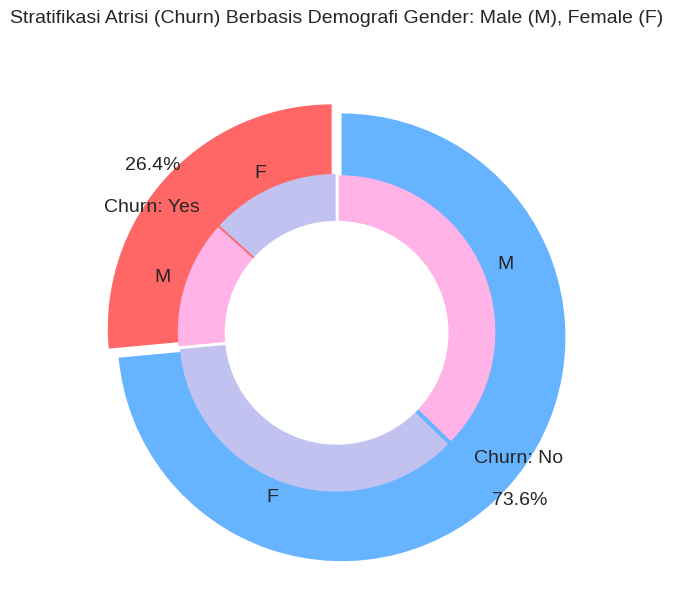

In [14]:
# Ekstraksi tabulasi silang agregat / Cross-tabulation mapping
cross_gender_churn = pd.crosstab(df['gender'], df['Churn'])

plt.figure(figsize=(6, 6))

# Agregat struktur lapisan luar / Outer layer (Macro Target)
labels_target_layer = ["Churn: Yes", "Churn: No"]
values_target_layer = [churn_counts.loc[1], churn_counts.loc[0]]

# Agregat struktur lapisan dalam / Inner layer (Micro Demographics)
labels_demographic_layer = ["F", "M", "F", "M"]
sizes_demographic_layer = [
    cross_gender_churn.loc['Female', 1],
    cross_gender_churn.loc['Male', 1],
    cross_gender_churn.loc['Female', 0],
    cross_gender_churn.loc['Male', 0]
]

# Konfigurasi profil palet & ruang grafis / Palette and spatial setup
colors_outer = ['#ff6666', '#66b3ff']
colors_inner = ['#c2c2f0', '#ffb3e6', '#c2c2f0', '#ffb3e6']
explode_outer = (0.3, 0.3)
explode_inner = (0.1, 0.1, 0.1, 0.1)
props_font = {"fontsize": 14}

# Render piringan lingkaran primer / Plot outer
plt.pie(
    values_target_layer, labels=labels_target_layer, autopct='%1.1f%%',
    pctdistance=1.08, labeldistance=0.8, colors=colors_outer,
    startangle=90, frame=True, explode=explode_outer,
    radius=10, textprops=props_font, counterclock=True
)

# Render piringan lingkaran sekunder / Plot inner
plt.pie(
    sizes_demographic_layer, labels=labels_demographic_layer,
    colors=colors_inner, startangle=90, explode=explode_inner,
    radius=7, textprops=props_font, counterclock=True
)

# Render pemotongan putih sentral / Superimpose center circle cutout
cutout_circle = plt.Circle((0,0), 5, color='black', fc='white', linewidth=0)
fig_nested = plt.gcf()
fig_nested.gca().add_artist(cutout_circle)

plt.title('Stratifikasi Atrisi (Churn) Berbasis Demografi Gender: Male (M), Female (F)', fontsize=14, y=1.1)
plt.axis('equal')
plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi *nested pie chart* pada grafik mengenai Stratifikasi Atrisi (Churn) Berbasis Demografi Gender, terdapat indikasi transisi data yang sangat penting dari skala makro menuju mikro kelompok demografis. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Homogenitas Perilaku Atrisi Antar Gender (*Homogeneity of Churn Behavior Across Gender*):** Pembagian sub-kelompok pada cincin bagian dalam menunjukkan bahwa proporsi pelanggan *Female* (F) dan *Male* (M) terbagi secara merata dan sangat seimbang, baik di dalam klaster pelanggan yang keluar (`Churn: Yes` sebesar 26.4%) maupun pelanggan yang bertahan (`Churn: No` sebesar 73.6%). Pola simetris ini menegaskan bahwa perilaku atrisi bersifat homogen di seluruh spektrum gender, sehingga variabel gender bukan merupakan *behavioral driver* (faktor pendorong perilaku) utama yang memicu risiko pelanggan memutuskan layanannya.

* **Efisiensi Fokus Strategi Retensi Operasional (*Operational Retention Strategy Efficiency*):** Karena risiko *churn* tidak berkonsentrasi pada salah satu gender tertentu, perusahaan disarankan untuk tidak mengalokasikan anggaran pada kampanye pemasaran atau retensi yang dipersonalisasi khusus berdasarkan segmentasi demografis gender (*gender-based demographic segmentation*). Sebaliknya, fokus kapabilitas dan investasi sumber daya tim retensi harus dialihkan ke penanganan faktor-faktor non-demografis yang bersifat operasional dan transaksional—seperti restrukturisasi tipe kontrak, kualitas dukungan teknis, serta penyesuaian tarif bulanan—karena variabel operasional tersebut memiliki pengaruh langsung yang jauh lebih kuat dalam menekan angka kebocoran pelanggan (*customer leakage*).

### **Hubungan Fitur Kategorikal Terhadap Atribusi Churn**

Eksplorasi bivariat dilakukan memetakan frekuensi dari segmentasi variabel layanan dan operasional terhadap proporsi *Churn*. Setiap variabel dikonstruksi ke dalam ruang render grafis Plotly secara spesifik untuk memfasilitasi visibilitas kategori yang mutlak.

In [15]:
# Pembuatan variabel proksi visual / Temporary visual dataframe rendering
df_visual_cat = df.copy()
df_visual_cat['Label_Target'] = df_visual_cat['Churn'].map({0: 'Retained (Loyal)', 1: 'Churned (Lost)'})
palette_bivariat = ['#4C72B0', '#DD8452']

In [16]:
# Analisis Bivariat Fitur: Partner
fig_partner = px.histogram(df_visual_cat, x='Partner', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Status Partner vs Churn")
fig_partner.update_layout(xaxis_title='Partner Status', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_partner.show()

Berdasarkan visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Status Partner vs Churn di atas, teridentifikasi adanya pengaruh elemen sosiodemografis yang kuat terhadap stabilitas portofolio pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Tingginya Proaktivitas Atrisi Segmen Mandiri (*Higher Attrition in Non-Partner Segment*):** Pelanggan yang tidak memiliki pasangan (`Partner Status = No`) menunjukkan volume *churn* yang jauh lebih masif (menyentuh kisaran 1.200 pelanggan) dengan rasio kelolosan yang signifikan dibandingkan pelanggan yang memiliki pasangan. Hal ini mengindikasikan bahwa pelanggan tanpa ikatan domestik memiliki mobilitas transaksional yang lebih longgar, membuat mereka jauh lebih sensitif terhadap pergerakan promo kompetitor dan rentan melakukan *brand switching*.

* **Efek Retensi Alami dari Struktur Rumah Tangga (*Family Account Stickiness Effect*):** Kelompok pelanggan dengan status memiliki pasangan (`Partner Status = Yes`) menunjukkan tingkat loyalitas yang jauh lebih solid. Dalam industri telekomunikasi, keberadaan pasangan sering kali berkorelasi dengan penggunaan utilitas bersama (*shared account* atau *household bundling*), yang secara alami menciptakan faktor keengganan berpindah (*switching barrier*) yang tinggi.

**Rekomendasi Strategis:** Tim komersial dapat memanfaatkan pola ini untuk merancang program loyalitas berbasis kemitraan, seperti *Family/Couple Bundling Package*. Strategi promosi ini bertujuan untuk mendorong pelanggan mandiri (*non-partner*) mengintegrasikan akun mereka dengan kerabat terdekat, guna meningkatkan retensi alami dan memperpanjang *Customer Lifetime Value* (CLV) secara agregat.

In [17]:
# Analisis Bivariat Fitur: Dependents
fig_dependents = px.histogram(df_visual_cat, x='Dependents', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Status Dependents vs Churn")
fig_dependents.update_layout(xaxis_title='Dependents Status', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_dependents.show()

Berdasarkan visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Status Dependents vs Churn di atas, terlihat kontras perilaku atrisi yang sangat jelas berdasarkan struktur tanggungan keluarga pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Tingginya Risiko Atrisi pada Segmen Mandiri (*High Churn Risk in Non-Dependent Segment*):** Pelanggan yang tidak memiliki tanggungan (`Dependents Status = No`) menyumbang volume *churn* terbesar (mencapai kisaran 1.500 pengguna) dengan proporsi atrisi yang jauh lebih tinggi. Segmen individu atau non-keluarga ini umumnya memiliki fleksibilitas tinggi tanpa ikatan domestik multi-pengguna, sehingga mereka jauh lebih sensitif terhadap pergerakan harga (*price-sensitive*) serta memiliki hambatan peralihan (*switching costs*) yang sangat rendah untuk berpindah ke kompetitor.

* **Efek Retensi Alami Paket Keluarga (*Family-Centric Stickiness Effect*):** Sebaliknya, kelompok pelanggan yang memiliki tanggungan (`Dependents Status = Yes`) menunjukkan pola loyalitas yang sangat solid dengan angka *churn* yang sangat minim (hanya sekitar 300 pengguna). Dalam ekosistem bisnis telekomunikasi, profil pelanggan berkeluarga biasanya mengadopsi produk multi-user seperti *shared family plans* atau layanan internet rumah (*fixed broadband*). Ketergantungan kolektif ini menciptakan *organic switching barrier* yang tinggi, karena pemutusan atau migrasi provider akan mengganggu konektivitas harian seluruh anggota keluarga.

**Rekomendasi Strategis:** Tim produk dan pemasaran dapat meluncurkan program kampanye retensi proaktif yang berfokus pada konversi pelanggan mandiri (`Dependents = No`) menuju paket berbasis komunitas atau keluarga (*household pooling account*). Dengan mendorong mereka mengintegrasikan layanan dengan lingkaran terdekatnya, perusahaan dapat meningkatkan loyalitas digital (*digital stickiness*) secara organik sekaligus mengunci kepastian pendapatan berulang (*recurring revenue*) jangka panjang.

In [18]:
# Analisis Bivariat Fitur: PhoneService
fig_phone = px.histogram(df_visual_cat, x='PhoneService', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Ketersediaan Phone Service vs Churn")
fig_phone.update_layout(xaxis_title='Phone Service Status', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_phone.show()

Berdasarkan visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Ketersediaan Phone Service vs Churn di atas, terlihat karakteristik kontribusi lini produk utama terhadap volume atrisi pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Volume Risiko pada Produk Inti (*Core Product Volume Risk*):** Layanan telepon (`Phone Service Status = Yes`) merupakan produk inti (*core product*) yang mengunci mayoritas absolut dari pangkalan pelanggan (*customer base*). Dampaknya, meskipun secara persentase terlihat berimbang, volume kehilangan pelanggan secara absolut berpusat pada segmen ini (mencapai kisaran 1.600+ pengguna). Hal ini menegaskan bahwa gangguan atau friksi sekecil apa pun pada lini produk utama akan langsung mendistorsi kestabilan arus kas operasional (*operational cash flow*) perusahaan secara masif.

* **Indikator Komoditas dan Kebutuhan Analisis Turunan (*Commoditized Feature & Need for Sub-feature Analysis*):** Proporsi komparatif antara pelanggan yang bertahan (*Retained*) dan yang keluar (*Churned*) menunjukkan rasio yang relatif serupa baik pada kelompok `Yes` maupun `No` (berada di sekitar tren makro ~26%). Pola konstan ini mengindikasikan bahwa kepemilikan akses telepon dasar secara independen telah menjadi komoditas dan bukan merupakan *key churn driver* (faktor pendorong utama) yang unik; oleh karena itu, tim analitik prediktif perlu membedah fitur turunan yang lebih spesifik—seperti adopsi multi-saluran (*Multiple Lines*) atau kestabilan paket internet bundling—untuk menemukan pola friksi yang memicu perpindahan pelanggan.

In [19]:
# Analisis Bivariat Fitur: MultipleLines
fig_lines = px.histogram(df_visual_cat, x='MultipleLines', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Adopsi Multiple Lines vs Churn")
fig_lines.update_layout(xaxis_title='Multiple Lines Usage', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_lines.show()

Berdasarkan visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Adopsi Multiple Lines vs Churn di atas, terdapat indikasi kontribusi fitur multi-saluran yang sangat krusial terhadap stabilitas pendapatan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Risiko Kebocoran Pendapatan Segmen Premium (*High-ARPU Revenue Leakage*):** Pelanggan yang mengadopsi layanan multi-saluran (`Multiple Lines = Yes`) menghasilkan kuantitas *churn* absolut yang sangat masif (sekitar 850 pengguna), hampir menyamai volume *churn* dari segmen pengguna lini tunggal (`No`). Mengingat pengguna *multi-lines* membayar biaya langganan yang lebih tinggi, fenomena ini merepresentasikan kerugian finansial yang jauh lebih besar bagi perusahaan. Kehilangan pelanggan di kelas ini berdampak ganda terhadap penurunan profitabilitas dan ARPU (*Average Revenue Per User*).

* **Ketiadaan Hambatan Peralihan Alami (*Absence of Structural Switching Barriers*):** Secara proporsional, rasio *churn* pada kelompok `Yes` cenderung sedikit lebih tinggi dibandingkan kelompok `No`. Pola ini membuktikan bahwa adopsi fitur premium berupa banyak saluran telepon tidak serta-merta menciptakan faktor keengganan berpindah (*stickiness effect*). Kelompok pengguna tingkat lanjut ini justru disinyalir lebih peka terhadap kualitas jaringan dan rentan beralih ke kompetitor apabila mendapati penawaran paket *bundling* atau *pricing model* korporat yang lebih kompetitif.

**Rekomendasi Strategis:** Tim retensi disarankan untuk mengunci loyalitas segmen *Multiple Lines* ini melalui strategi penawaran nilai tambah (*value-added incentives*) yang tidak dimiliki kompetitor—seperti integrasi gratis dengan proteksi digital (`Online Security`) atau prioritas penanganan keluhan (*VIP tech support*)—guna menaikkan biaya emosional untuk berpindah provider (*switching costs*).

In [20]:
# Analisis Bivariat Fitur: InternetService
fig_internet = px.histogram(df_visual_cat, x='InternetService', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Tipe Internet Service vs Churn")
fig_internet.update_layout(xaxis_title='Internet Service Type', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_internet.show()

Berdasarkan visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Tipe Internet Service vs Churn di atas, teridentifikasi sebuah anomali kritikal terkait perilaku atrisi pada pengguna infrastruktur utama perusahaan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Krisis Atrisi pada Infrastruktur Premium (*Fiber Optic Churn Crisis*):** Segmen pelanggan yang menggunakan layanan *Fiber optic* menyumbang angka *churn* absolut yang paling masif (mencapai kisaran 1.300 pengguna) dengan proporsi atrisi yang sangat tinggi (mendekati 42%). Mengingat *Fiber optic* merupakan lini produk premium dengan kontribusi ARPU (*Average Revenue Per User*) tertinggi, fenomena ini mengindikasikan adanya masalah struktural serius—seperti isu stabilitas kualitas jaringan, lambatnya penanganan komplain, atau ketidaksesuaian antara ekspektasi harga tinggi dengan nilai yang dirasakan pelanggan (*price-to-value mismatch*).

* **Loyalitas Tinggi di Segmen Tradisional (*High Retention in DSL and Non-Internet Segments*):** Sebaliknya, pelanggan dengan layanan *DSL* menunjukkan tingkat loyalitas yang jauh lebih stabil, dan segmen tanpa layanan internet (`No`) mencatatkan risiko atrisi terendah (hanya sekitar 6%). Pola ini membuktikan bahwa kelompok pengguna layanan non-premium atau pelanggan telepon dasar memiliki tingkat kepuasan yang lebih konsisten karena kebutuhan mereka yang sederhana, sehingga memiliki sensitivitas yang rendah terhadap pergerakan taktik promosi kompetitor.

**Rekomendasi Operasional:** Manajemen harus segera memprioritaskan audit teknis dan mengikat loyalitas pangkalan pelanggan *Fiber optic* melalui strategi *bundling* proaktif dengan layanan proteksi digital atau jaminan prioritas dukungan teknis (*VIP Tech Support*) guna menahan laju kebocoran pendapatan utama (*revenue leakage*) perusahaan.

In [21]:
# Analisis Bivariat Fitur: OnlineSecurity
fig_security = px.histogram(df_visual_cat, x='OnlineSecurity', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Langganan Online Security vs Churn")
fig_security.update_layout(xaxis_title='Online Security Subscription', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_security.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Langganan Online Security vs Churn di atas, terlihat dampak penetrasi layanan keamanan digital yang sangat signifikan dalam menekan angka atrisi pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Layanan Tambahan sebagai Jangkar Loyalitas (*Value-Added Service Stickiness*):** Pelanggan yang mengaktifkan fitur `Online Security` (`Yes`) memiliki rasio *churn* yang sangat minim (hanya sekitar 300 pengguna) dengan tingkat retensi yang sangat solid. Temuan ini membuktikan bahwa perlindungan siber bertindak sebagai layanan bernilai tambah (*Value-Added Services*) yang efektif mengunci loyalitas digital pelanggan, karena menciptakan hambatan peralihan (*switching barriers*) yang lebih tinggi dari sisi kenyamanan dan keamanan data.

* **Episentrum Kerentanan Risiko Atrisi (*Epicenter of Vulnerability in Non-Protected Users*):** Sebaliknya, segmen pengguna internet yang tidak berlangganan fitur keamanan (`No`) menjadi kontributor *churn* absolut terbesar (mencapai kisaran 1.450 pengguna) dengan proporsi atrisi yang sangat masif. Kelompok ini merupakan titik paling rapuh di mana pelanggan dengan mudah berpindah ke kompetitor; kemungkinan besar karena mereka merasa nilai layanan (*perceived value*) paket internet biasa kurang kompetitif jika tidak dibekali proteksi penuh.

**Rekomendasi Operasional:** Perusahaan dapat menekan laju *customer leakage* secara drastis dengan menerapkan strategi *default bundling*, yaitu mengintegrasikan layanan *Online Security* secara langsung ke dalam paket internet utama (terutama bagi pengguna *Fiber Optic* yang sebelumnya terdeteksi memiliki risiko *churn* tinggi) atau memberikan insentif berupa uji coba gratis (*free-trial*) pada fase *onboarding* pelanggan baru.

In [22]:
# Analisis Bivariat Fitur: OnlineBackup
fig_backup = px.histogram(df_visual_cat, x='OnlineBackup', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Langganan Online Backup vs Churn")
fig_backup.update_layout(xaxis_title='Online Backup Subscription', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_backup.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Langganan Online Backup vs Churn di atas, teridentifikasi peran krusial dari layanan pencadangan data dalam memperkuat retensi dan menciptakan keterikatan digital pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Efek Penguncian Data sebagai Jangkar Loyalitas (*Data Lock-in & Retention Anchor*):** Pelanggan yang mengaktifkan fitur `Online Backup` (`Yes`) menunjukkan tingkat loyalitas yang sangat solid dengan volume *churn* yang relatif rendah (sekitar 500 pengguna). Di industri telekomunikasi, penyimpanan awan (*cloud storage*) bertindak sebagai fitur utilitas yang menciptakan hambatan peralihan (*switching barriers*) yang tinggi secara praktis. Pelanggan cenderung enggan bermigrasi ke kompetitor demi menghindari kerumitan migrasi data atau risiko hilangnya berkas berharga mereka.

* **Titik Kebocoran Masif pada Segmen Non-Backup (*Epicenter of Churn in Non-Backup Segment*):** Sebaliknya, segmen pengguna internet yang tidak mengadopsi fitur pencadangan data (`No`) menjadi kontributor utama atrisi dengan volume *churn* absolut yang sangat mengkhawatirkan (menyentuh kisaran 1.200 pengguna). Kelompok ini memiliki kelekatan produk (*product stickiness*) yang rendah karena mengonsumsi internet sebagai komoditas dasar saja, sehingga mereka sangat rentan berpindah provider saat dihadapkan pada promo harga murah dari kompetitor.

**Rekomendasi Operasional:** Tim produk dan pemasaran disarankan untuk menekan laju *customer leakage* pada klaster `No` ini melalui strategi penawaran bersilang (*cross-selling*) yang agresif. Perusahaan dapat memberikan insentif berupa kuota *cloud storage* gratis selama 3 bulan pertama atau menggabungkannya ke dalam skema *Value-Added Services* (VAS) bernilai tinggi, guna menaikkan biaya emosional pelanggan untuk berpindah layanan (*switching costs*).

In [23]:
# Analisis Bivariat Fitur: DeviceProtection
fig_device = px.histogram(df_visual_cat, x='DeviceProtection', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Perlindungan Perangkat (Device Protection) vs Churn")
fig_device.update_layout(xaxis_title='Device Protection Plan', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_device.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Perlindungan Perangkat (Device Protection) vs Churn di atas, terlihat kontras yang jelas mengenai kontribusi proteksi gawai terhadap ketahanan pangkalan pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Retensi Kuat Melalui Proteksi Finansial Perangkat (*Device Protection Stickiness Effect*):** Pelanggan yang mengaktifkan fitur `Device Protection` (`Yes`) menunjukkan tingkat loyalitas yang jauh lebih kokoh dengan volume *churn* yang tereduksi secara signifikan (hanya sekitar 550 pengguna). Skema asuransi atau perlindungan gawai ini berfungsi sebagai jangkar retensi operasional yang efektif karena menaikkan hambatan peralihan (*switching barriers*), di mana pelanggan cenderung enggan kehilangan hak proteksi atas perangkat keras mereka jika bermigrasi ke provider lain.

* **Episentrum Risiko pada Klaster Tanpa Perlindungan (*High Attrition in Unprotected Users*):** Sebaliknya, kelompok pengguna internet yang memilih tidak menggunakan fitur perlindungan perangkat (`No`) menjadi hotspot kebocoran pelanggan terbesar dengan volume *churn* absolut tertinggi (mencapai kisaran 1.200 pengguna). Ketiadaan ikatan proteksi tambahan ini membuat pelanggan memandang layanan sebagai komoditas murni tanpa nilai tambah (*perceived value* rendah), sehingga mereka menjadi sangat peka terhadap harga dan rentan melakukan *brand switching* saat didekati oleh kompetitor.

**Rekomendasi Operasional:** Tim komersial dapat menekan laju *customer leakage* dengan merancang strategi promosi bersilang (*cross-selling*) proaktif, seperti menawarkan diskon biaya perlindungan perangkat khusus bagi pelanggan di klaster `No` yang menggunakan paket internet premium (*Fiber Optic*), guna mengunci loyalitas digital mereka secara jangka panjang.

In [24]:
# Analisis Bivariat Fitur: TechSupport
fig_tech = px.histogram(df_visual_cat, x='TechSupport', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Akses Tech Support vs Churn")
fig_tech.update_layout(xaxis_title='Technical Support Access', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_tech.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Akses Tech Support vs Churn di atas, terlihat korelasi yang sangat kuat antara ketersediaan dukungan teknis dan tingkat retensi pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Dukungan Teknis sebagai Faktor Krusial Retensi (*Tech Support as a Critical Retention Anchor*):** Pelanggan yang mengaktifkan fitur `TechSupport` (`Yes`) menunjukkan tingkat loyalitas yang luar biasa tinggi dengan volume *churn* yang sangat minim (hanya sekitar 300 pengguna). Hal ini membuktikan bahwa penyelesaian kendala teknis secara proaktif dan layanan asistensi yang responsif berhasil menekan rasa frustrasi pengguna, meningkatkan kepuasan layanan, serta secara efektif mengunci loyalitas pelanggan.

* **Episentrum Kebocoran Pelanggan Akibat Kendala Teknis (*Epicenter of Attrition in Unsupported Users*):** Sebaliknya, kelompok pelanggan internet yang tidak memiliki akses ke dukungan teknis (`No`) menjadi hotspot *churn* absolut terbesar dengan volume atrisi yang sangat mengkhawatirkan (mencapai kisaran 1.450 pengguna). Tingginya angka kehilangan pelanggan di segmen ini mengindikasikan bahwa masalah jaringan atau kendala operasional yang tidak ditangani dengan cepat menjadi pemicu utama (*key driver*) yang mendorong pengguna memutus layanan dan beralih ke kompetitor.

**Rekomendasi Operasional:** Perusahaan dapat menekan laju *customer leakage* secara drastis dengan merancang program retensi proaktif berupa pemberian komplemen *VIP Tech Support* atau jaminan penanganan cepat tanpa biaya tambahan bagi kelompok pengguna internet berbiaya tinggi (seperti pengguna *Fiber Optic*), guna meningkatkan *perceived value* sekaligus memperpanjang siklus hidup pelanggan.

In [25]:
# Analisis Bivariat Fitur: StreamingTV
fig_tv = px.histogram(df_visual_cat, x='StreamingTV', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Penggunaan Layanan Streaming TV vs Churn")
fig_tv.update_layout(xaxis_title='Streaming TV Usage', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_tv.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Penggunaan Layanan Streaming TV vs Churn di atas, teridentifikasi karakteristik kontribusi layanan hiburan tambahan terhadap volume dan rasio atrisi pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Efek Retensi Moderat dari Layanan Hiburan (*Modest Stickiness of Entertainment Add-ons*):** Pelanggan yang mengaktifkan fitur `Streaming TV` (`Yes`) menunjukkan jumlah absolut dan proporsi *churn* yang sedikit lebih rendah (sekitar 800 pengguna) dibandingkan kelompok pengguna internet yang tidak menggunakan layanan ini (`No`, sekitar 950 pengguna). Temuan ini mengindikasikan bahwa integrasi konten hiburan bertindak sebagai nilai tambah (*value-added feature*) yang mampu mendongkrak kepuasan harian konsumen secara moderat, sehingga sedikit menahan laju perpindahan provider.

* **Tantangan Sistemik pada Segmen Pengguna Internet (*Core Internet Segment Vulnerability*):** Meskipun adopsi *Streaming TV* memberikan efek retensi positif, volume *churn* pada kedua klaster pengguna internet (`Yes` dan `No`) tetap terpantau sangat tinggi secara kontras jika dibandingkan dengan klaster non-internet (`No internet service`). Pola ini menegaskan bahwa pemicu utama kegagalan retensi bukan bersumber dari fungsionalitas konten medianya, melainkan dari faktor fundamental ekosistem internet itu sendiri—seperti stabilitas jaringan dasar, kuota, atau skema harga paket *broadband*—yang memerlukan evaluasi operasional lebih mendalam.

In [26]:
# Analisis Bivariat Fitur: StreamingMovies
fig_movies = px.histogram(df_visual_cat, x='StreamingMovies', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Penggunaan Layanan Streaming Movies vs Churn")
fig_movies.update_layout(xaxis_title='Streaming Movies Usage', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_movies.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Penggunaan Layanan Streaming Movies vs Churn di atas, terlihat pola karakteristik retensi pelanggan yang didorong oleh adopsi layanan hiburan digital. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Dampak Retensi Marginal dari Layanan Konten (*Marginal Retention Impact of Content Add-ons*):** Pelanggan yang mengaktifkan fitur `Streaming Movies` (`Yes`) menunjukkan jumlah absolut dan proporsi *churn* yang sedikit lebih rendah (sekitar 800 pengguna) dibandingkan dengan kelompok pengguna internet yang tidak mengadopsi layanan ini (`No`, sekitar 930 pengguna). Temuan ini mengindikasikan bahwa integrasi konten media interaktif mampu meningkatkan keterikatan digital (*digital engagement*) pelanggan, sehingga memberikan sedikit kontribusi positif dalam menahan laju perpindahan ke provider lain.

* **Atrisi Berpusat pada Ekosistem Konektivitas Utama (*Attrition Centered on Core Connectivity Ecosystem*):** Meskipun adopsi fitur film streaming memberikan efek proteksi loyalitas yang moderat, volume *churn* pada kedua klaster pengguna internet (`Yes` dan `No`) tetap terpantau sangat masif secara kontras dibandingkan klaster non-internet (`No internet service`). Pola ini menegaskan bahwa pemicu utama kegagalan retensi bukan bersumber dari fungsionalitas produk hiburan tambahan tersebut, melainkan dari faktor fundamental pada layanan *broadband* inti—seperti kesesuaian harga paket, kuota, atau stabilitas jaringan internet dasar—yang memerlukan evaluasi struktural oleh tim manajemen produk.

In [27]:
# Analisis Bivariat Fitur: Contract
fig_contract = px.histogram(df_visual_cat, x='Contract', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Term Kontrak (Contract Type) vs Churn")
fig_contract.update_layout(xaxis_title='Contract Type', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_contract.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Term Kontrak (Contract Type) vs Churn di atas, teridentifikasi bahwa jenis kontrak merupakan faktor pendorong paling kritikal (*primary churn driver*) yang memengaruhi keputusan atrisi pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Episentrum Kerentanan Kontrak Bulanan (*Severe Month-to-Month Churn Vulnerability*):** Pelanggan dengan tipe kontrak *Month-to-month* menjadi penyumbang volume *churn* terbesar secara absolut (mencapai kisaran 1.600+ pengguna) dengan proporsi atrisi yang sangat mengkhawatirkan. Fleksibilitas tanpa komitmen ini membuat pelanggan tidak memiliki hambatan finansial (*switching costs*) atau penalti pemutusan hubungan, sehingga mereka sangat rentan melakukan *brand switching* seketika saat mendapati friksi layanan atau terpapar promo kompetitor.

* **Efektivitas Penguncian Finansial Kontrak Jangka Panjang (*Long-Term Contract Lock-in Effect*):** Sebaliknya, pada segmen kontrak *One year* dan *Two year*, kuantitas *churn* menurun secara drastis hingga hampir menyentuh titik minimal pada kontrak dua tahun. Komitmen formal ini bertindak sebagai *structural barrier* yang sangat kuat untuk mengunci loyalitas pelanggan, mengamankan kepastian arus kas berulang (*recurring revenue*), serta memaksimalkan kapabilitas *Customer Lifetime Value* (CLV) secara agregat.

**Rekomendasi Operasional:** Tim komersial harus memprioritaskan strategi intervensi proaktif dengan merancang program insentif migrasi guna mendorong kelompok pengguna *Month-to-month* beralih ke kontrak minimal 1 tahun. Kampanye ini dapat diakselerasi melalui penawaran skema *price lock* (jaminan harga tetap), diskon tarif bulanan (*discounted monthly rate*), atau gratis peningkatan fasilitas layanan (*free upgrade features*) pada bulan-bulan awal kontrak baru.

In [28]:
# Analisis Bivariat Fitur: PaperlessBilling
fig_billing = px.histogram(df_visual_cat, x='PaperlessBilling', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Adopsi Paperless Billing vs Churn")
fig_billing.update_layout(xaxis_title='Paperless Billing Usage', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=800)
fig_billing.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Adopsi Paperless Billing vs Churn di atas, ditemukan korelasi yang cukup unik dan kontras antara metode penagihan digital dengan tingkat atrisi pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Tingginya Sensitivitas Biaya pada Segmen Digital (*Digital Invoice Shock & High Attrition*):** Pelanggan yang mengaktifkan fitur `Paperless Billing` (`Yes`) menyumbang volume *churn* terbesar secara absolut (mencapai kisaran 1.400 pengguna) dengan proporsi atrisi yang jauh lebih tinggi. Dalam psikologi konsumen industri loyalitas, fenomena ini erat kaitannya dengan efek transparansi tagihan (*bill salience effect*). Notifikasi tagihan digital yang masuk secara agresif via email atau SMS setiap bulan secara psikologis memicu pengguna untuk terus memantau pengeluaran mereka, sehingga membuat mereka jauh lebih peka terhadap harga (*price-sensitive*) dan proaktif mencari alternatif provider yang lebih murah.

* **Kelekatan Rutinitas pada Segmen Tradisional (*Inertia and Stability in Traditional Billing*):** Sebaliknya, kelompok pelanggan yang mempertahankan metode penagihan konvensional (`No`) menunjukkan profil loyalitas yang jauh lebih kokoh dengan angka *churn* yang minim (sekitar 450 pengguna). Kelompok ini umumnya didominasi oleh profil pelanggan konvensional yang mengutamakan rutinitas statis atau memiliki mekanisme pembayaran otomatis (*auto-debit*), sehingga menciptakan hambatan perilaku (*behavioral inertia*) yang tinggi untuk berpindah provider karena rendahnya interaksi evaluatif terhadap nominal tagihan bulanan.

**Rekomendasi Operasional:** Perusahaan tidak boleh menghentikan program *paperless* karena efisiensi biaya cetak, namun tim pemasaran digital harus mengubah strategi penagihan. Alih-alih hanya mengirimkan rincian biaya, lampirkan visualisasi performa utilitas (seperti total kuota yang dihemat atau kecepatan rata-rata yang dinikmati) di dalam surat surat tagihan elektronik (*e-invoice*) tersebut. Langkah ini krusial untuk mengubah persepsi pelanggan dari "melihat beban biaya" menjadi "melihat nilai manfaat" (*shifting from cost to value perception*) demi menekan laju *customer leakage*.

In [108]:
# Analisis Bivariat Fitur: PaymentMethod
fig_payment = px.histogram(df_visual_cat, x='PaymentMethod', color="Label_Target", barmode="group", color_discrete_sequence=palette_bivariat, title="Relasi Bivariat: Saluran Metode Pembayaran vs Churn")
fig_payment.update_layout(xaxis_title='Payment Method Options', yaxis_title="Kuantitas Pengguna", legend_title="Target Klasifikasi", height=400, width=900)
fig_payment.show()

Berdasarkan hasil visualisasi histogram bivariat pada grafik mengenai Relasi Bivariat: Saluran Metode Pembayaran vs Churn di atas, ditemukan kontras perilaku atrisi yang sangat mencolok antara saluran pembayaran manual dan otomatis. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Krisis Atrisi pada Transaksi Non-Otomatis (*Electronic Check Churn Crisis*):** Pelanggan yang memilih metode pembayaran *Electronic check* menjadi episentrum kebocoran pendapatan terbesar dengan volume *churn* absolut yang sangat masif (mencapai kisaran 1.050+ pengguna), hampir menyamai jumlah pelanggan yang bertahan di kelas tersebut. Tingginya angka atrisi ini mengindikasikan adanya friksi transaksional bulanan yang tinggi—seperti masalah kegagalan sistem pembayaran manual atau efek psikologis *bill salience* (pelanggan harus bertransaksi secara aktif setiap bulan, sehingga mereka terus-menerus mengevaluasi urgensi pengeluaran tersebut dan lebih sensitif terhadap promo kompetitor).

* **Efek Retensi Alami Penagihan Otomatis (*Automatic Billing as a Retention Anchor*):** Sebaliknya, kelompok pembayaran berbasis otomatis, baik melalui *Bank transfer (automatic)* maupun *Credit card (automatic)*, terbukti menjadi jangkar loyalitas digital yang paling kokoh dengan angka *churn* terendah. Mekanisme penagihan tanpa hambatan (*frictionless billing*) lewat sistem *auto-debit* berhasil mengeliminasi rutinitas transaksi manual yang mengganggu kenyamanan pelanggan. Hal ini menciptakan hambatan perilaku alami (*behavioral inertia*), di mana pelanggan cenderung mempertahankan layanan dalam jangka panjang karena tidak perlu melewati proses administrasi penagihan berulang.

**Rekomendasi Operasional:** Tim pertumbuhan (*growth team*) dan finansial harus segera merancang program insentif migrasi untuk menekan laju *customer leakage* pada segmen *Electronic check*. Perusahaan dapat menawarkan potongan harga langsung (*cashback/discount*) pada tagihan bulan berikutnya atau memberikan bonus kuota gratis jika pelanggan bersedia mengaktifkan fitur pembayaran otomatis (*auto-debit*) menggunakan kartu kredit atau transfer bank.

### **Kepadatan Probabilitas Finansial (Numeric Kernel Density)**

Pemetaan kurva halus terhadap frekuensi distribusi dari komponen tagihan diimplementasikan melalui pendekatan *Density Histogram*. Parameter pewarnaan divergensi disetel bervariasi agar kemudahan identifikasi diferensiasi area kelas tetap prima.

In [30]:
# Re-instansiasi vektor proksi untuk manipulasi grafik kontinu / Numeric visual mapping
df_visual_num = df.copy()
df_visual_num['Label_Target'] = df_visual_num['Churn'].map({0: 'Retained (Loyal)', 1: 'Churned (Lost)'})

In [31]:
# Kepadatan Histogram Fitur: Tenure
fig_dens_tenure = px.histogram(df_visual_num, x='tenure', color="Label_Target", barmode="overlay", histnorm="density", color_discrete_sequence=['#1f77b4', '#d62728'], title="Pemetaan Kepadatan Probabilitas: Durasi Langganan (Tenure)")
fig_dens_tenure.update_layout(xaxis_title='Tenure (Bulan)', yaxis_title="Kerapatan Distribusi / Density", legend_title="Target Klasifikasi", height=400, width=800)
fig_dens_tenure.show()

Berdasarkan visualisasi grafik distribusi mengenai Pemetaan Kepadatan Probabilitas: Durasi Langganan (Tenure) di atas, teridentifikasi pola polarisasi ekstrem yang membagi siklus hidup pelanggan (*customer life cycle*) menjadi dua fase kritis. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Fenomena Atrisi Dini (*Infant Mortality & Early Churn Spike*):** Kepadatan data pelanggan yang keluar (`Churned (Lost)`) menumpuk secara agresif pada rentang *tenure* awal, khususnya di bulan ke-0 hingga ke-5. Lonjakan atrisi instan ini menandakan adanya masalah krusial pada fase awal penggunaan, seperti ketidaksesuaian ekspektasi layanan, buruknya proses *onboarding*, atau kejutan tagihan pertama (*first bill shock*). Jendela awal ini merupakan zona bahaya utama di mana intervensi *customer success* secara proaktif wajib dilakukan demi menyelamatkan investasi biaya akuisisi pelanggan (*Customer Acquisition Cost*).

* **Kelekatan Jangka Panjang (*The Longevity Lock-in Effect*):** Sebaliknya, kepadatan pelanggan yang bertahan (`Retained (Loyal)`) menunjukkan lonjakan masif di ujung kurva, tepatnya pada masa langganan di atas 60 hingga 72 bulan. Pola ini membuktikan bahwa risiko *churn* akan menurun secara eksponensial seiring berjalannya waktu. Begitu pelanggan berhasil melewati masa transisi 20 bulan pertama, kelekatan produk (*product stickiness*) dan hambatan perpindahan (*switching costs*) mereka akan meningkat secara alami, menjadikan mereka sebagai pangkalan aset *Customer Lifetime Value* (CLV) yang paling kokoh dan bernilai tinggi bagi perusahaan.

In [32]:
# Kepadatan Histogram Fitur: MonthlyCharges
fig_dens_monthly = px.histogram(df_visual_num, x='MonthlyCharges', color="Label_Target", barmode="overlay", histnorm="density", color_discrete_sequence=['#2ca02c', '#9467bd'], title="Pemetaan Kepadatan Probabilitas: Beban Tagihan Bulanan (Monthly Charges)")
fig_dens_monthly.update_layout(xaxis_title='Monthly Charges (USD)', yaxis_title="Kerapatan Distribusi / Density", legend_title="Target Klasifikasi", height=400, width=800)
fig_dens_monthly.show()

Berdasarkan visualisasi grafik distribusi mengenai Pemetaan Kepadatan Probabilitas: Beban Tagihan Bulanan (Monthly Charges) di atas, teridentifikasi korelasi non-linear yang sangat kuat antara besaran nominal pengeluaran bulanan pelanggan dengan risiko atrisi mereka. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Zona Aman Retensi pada Tarif Ekonomis (*Low-Price Retention Safe Haven*):** Pada rentang biaya bulanan rendah (di kisaran 20 USD), terlihat lonjakan kepadatan yang sangat masif bagi pelanggan yang bertahan (`Retained (Loyal)`). Pelanggan di segmen ini umumnya hanya mengonsumsi layanan telepon dasar atau paket utilitas minimal. Karena beban finansialnya yang sangat rendah, kelompok ini memiliki sensitivitas harga yang minimal dan cenderung bersikap inersia (enggan repot berpindah provider), sehingga menjadi jangkar kestabilan pangkalan pelanggan.

* **Titik Kritis Atrisi pada Segmen Premium (*Premium ARPU Churn Hotspot*):** Sebaliknya, pada rentang biaya tinggi (kisaran 70 hingga 100 USD), proporsi pelanggan yang keluar (`Churned (Lost)`) meningkat secara drastis dan membentuk area akumulasi risiko yang padat. Kelompok ini merupakan pengguna bernilai tinggi (*high-value customers*) yang kemungkinan besar mengadopsi paket *Fiber Optic* beserta berbagai layanan tambahan (*Value-Added Services*). Tingginya angka *churn* di segmen ini mengindikasikan adanya masalah *price-to-value mismatch* (pelanggan merasa kualitas layanan tidak sebanding dengan mahalnya tagihan), yang merepresentasikan ancaman kerugian pendapatan (*revenue leakage*) terbesar bagi profitabilitas perusahaan karena tingginya nilai ARPU (*Average Revenue Per User*) yang hilang.

**Rekomendasi Operasional:** Manajemen produk harus segera melakukan evaluasi elastisitas harga dan merancang program "Premium Customer Care" khusus untuk pelanggan dengan tagihan di atas 70 USD. Strategi intervensi dapat berupa pemberian diskon loyalitas otomatis, kuota bonus, atau penyesuaian tarif berkala guna mereduksi *bill shock* (kejutan tagihan) tanpa harus menurunkan kualitas layanan inti.

In [33]:
# Kepadatan Histogram Fitur: TotalCharges
fig_dens_total = px.histogram(df_visual_num, x='TotalCharges', color="Label_Target", barmode="overlay", histnorm="density", color_discrete_sequence=['#17becf', '#ff7f0e'], title="Pemetaan Kepadatan Probabilitas: Akumulasi Tagihan Total (Total Charges)")
fig_dens_total.update_layout(xaxis_title='Total Charges (USD)', yaxis_title="Kerapatan Distribusi / Density", legend_title="Target Klasifikasi", height=400, width=800)
fig_dens_total.show()

Berdasarkan visualisasi grafik distribusi mengenai Pemetaan Kepadatan Probabilitas: Akumulasi Tagihan Total (Total Charges) di atas, teridentifikasi korelasi yang kuat antara total akumulasi kontribusi finansial pelanggan dengan tingkat loyalitas mereka. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Kebocoran Nilai Finansial di Fase Awal (*Early-Stage Financial Value Leakage*):** Kepadatan pelanggan yang keluar (`Churned (Lost)`) menumpuk secara ekstrem pada rentang akumulasi tagihan yang sangat rendah (di bawah 500 USD). Pola ini mengonfirmasi bahwa mayoritas atrisi terjadi sebelum pelanggan sempat menghasilkan nilai ekonomi yang signifikan bagi perusahaan. Fenomena ini merugikan profitabilitas karena perusahaan kehilangan potensi pendapatan sebelum berhasil mencapai titik impas (*break-even point*) atas Biaya Akuisisi Pelanggan (*Customer Acquisition Cost*).

* **Efek Penguncian Nilai Kumulatif (*High Lifetime Spend Stickiness Effect*):** Sebaliknya, pada rentang *Total Charges* menengah hingga tinggi (di atas 2.000 USD hingga menyentuh 8.000 USD), kurva pelanggan yang bertahan (`Retained (Loyal)`) mendominasi secara konsisten, sementara kerapatan kurva *churn* melandai hingga titik minimal. Hal ini membuktikan bahwa pelanggan yang telah menginvestasikan dana kumulatif besar memiliki tingkat kelekatan (*stickiness*) yang sangat tinggi. Besarnya nominal yang telah dibayarkan menciptakan hambatan peralihan psikologis (*sunk cost fallacy/behavioral switching cost*), sehingga kelompok pelanggan matang ini menjadi pilar penopang stabilitas *Customer Lifetime Value* (CLV) jangka panjang.

## **Feature Engineering**

### **Transformasi Matriks Kategorikal dan Normalisasi**

Arsitektur algoritma *Machine Learning* hanya dapat memproses matriks berformat komputasi angka riil. Transformasi variabel nominal menuju representasi biner ortogonal dieksekusi via mekanisme *One-Hot Encoding*. Untuk mensinkronisasikan bobot fitur angka nominal berinterval besar, standardisasi variabel via distribusi Z-score diaplikasikan.

Formula Standardisasi Skala (*Z-score Normalization*):

$$z = \frac{x - \mu}{\sigma}$$

**Keterangan:**
* $z$: Hasil skalar dari vektor numerik yang telah ditransformasi dalam limit rentang deviasi absolut.
* $x$: Struktur nilai matriks variabel asal pra-konversi.
* $\mu$: Hasil komputasi rata-rata global (*mean expectation*) populasi referensi observasional.
* $\sigma$: Estimasi dispersi deviasi standar (*standard deviation*) pada fitur subjek.

In [34]:
# Pemisahan ruang fitur pemodelan (Features X) dan label (Target y) / Isolate matrices
X = df.drop('Churn', axis=1)
y = df['Churn']

# Re-identifikasi kolom obyek untuk perlakuan biner / Enlist string types
all_categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Penciptaan matriks bayangan orthogonal / One-Hot Encoding mapping
X_encoded = pd.get_dummies(X, columns=all_categorical_cols, drop_first=True)

# Pembelahan alokasi sampel dataset untuk latihan (80%) dan pengetesan model (20%) / Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Pengkalibrasian skalar distribusi agar selaras dari efek bias / Scaling pipeline setup
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Dimensi Aktual Matriks Training (X_train) : {X_train.shape}")
print(f"Dimensi Aktual Matriks Pengujian (X_test) : {X_test.shape}")

Dimensi Aktual Matriks Training (X_train) : (5616, 30)
Dimensi Aktual Matriks Pengujian (X_test) : (1405, 30)


Berdasarkan output dimensi matriks data untuk pemodelan *machine learning* di atas, terlihat kesiapan data yang sangat matang dan terstruktur untuk membangun model prediksi *churn* pelanggan telekomunikasi. Berikut adalah wawasan bisnis (*business insights*) singkat terkait karakteristik dimensi data tersebut:

* **Rasio Pembagian Data yang Ideal (*Robust Golden Split Ratio*):** Total pangkalan pelanggan yang dianalisis mencakup **7.021 pengguna**, dengan pembagian data *training* (**5.616 baris**) dan *testing* (**1.405 baris**) yang menerapkan rasio ideal **80:20**. Volume data yang masif pada matriks latihan memberikan fondasi yang sangat kokoh bagi model prediktif untuk mempelajari variabilitas perilaku pelanggan tanpa risiko kekurangan sampel (*underfitting*). Sementara itu, ukuran data pengujian yang mencapai ribuan baris memastikan bahwa akurasi model yang dihasilkan nantinya benar-benar valid, objektif, dan siap diuji coba pada operasional retensi nyata.

* **Profil Pelanggan 360 Derajat (*High-Dimensional Customer Profiles*):** Keberadaan **30 fitur (*features*) prediktor** menandakan bahwa perusahaan memiliki arsitektur data pelanggan yang sangat kaya (*multidimensional data*). Metrik ini mengonfirmasi keterlibatan seluruh dimensi krusial secara komprehensif—mulai dari data penggunaan layanan inti, adopsi proteksi tambahan (*Value-Added Services*), perilaku finansial (biaya bulanan dan tipe kontrak), hingga profil sosiodemografi. Kompleksitas fitur ini memungkinkan model untuk menangani pola interaksi tersembunyi antar-variabel guna mendeteksi sinyal-sinyal awal kecenderungan *churn* yang samar dengan tingkat presisi yang tinggi.

## **Hyperparameter Tuning dan Baseline Evaluation**

### **Pengujian Batas Ambang Baseline (Baseline Benchmarking)**

Guna menetapkan indikator pengukur metrik fundamental (*baseline threshold*), model estimator awal dibangun menggunakan arsitektur hiperparameter dasar (*default configuration*). Pendekatan ini memastikan justifikasi fungsional dari optimisasi model pada tahapan pencarian terpandu (*Hyperparameter tuning*) lebih terukur dampaknya terhadap *Return on Investment* (ROI) proses komputasi.

In [35]:
# Deklarasi kerangka arsitektur fundamental awal / Initialize default base models
logreg_baseline = LogisticRegression(random_state=42)
rf_baseline = RandomForestClassifier(random_state=42)
xgb_baseline = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Mengasimilasikan model tanpa optimasi pada memori data train / Fit base patterns
logreg_baseline.fit(X_train, y_train)
rf_baseline.fit(X_train, y_train)
xgb_baseline.fit(X_train, y_train)

# Mencetak utilitas kapasitas model dasar / Extract raw probability metrics
print("=== Rapor Threshold Dasar: Metrik Evaluasi ROC-AUC (Baseline) ===")
print(f"Logistic Regression : {roc_auc_score(y_test, logreg_baseline.predict_proba(X_test)[:, 1]):.4f}")
print(f"Random Forest       : {roc_auc_score(y_test, rf_baseline.predict_proba(X_test)[:, 1]):.4f}")
print(f"XGBoost             : {roc_auc_score(y_test, xgb_baseline.predict_proba(X_test)[:, 1]):.4f}")

=== Rapor Threshold Dasar: Metrik Evaluasi ROC-AUC (Baseline) ===
Logistic Regression : 0.8405
Random Forest       : 0.8171
XGBoost             : 0.8118


Berdasarkan rincian evaluasi awal (*baseline*) metrik ROC-AUC di atas, terlihat performa model statistik konvensional secara mengejutkan mampu mengungguli model berbasis pohon (*tree-based models*) dalam mengidentifikasi risiko atrisi pelanggan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Dominasi Baseline Logistic Regression (*Superior Linearity & Interpretability*):** `Logistic Regression` mencatatkan skor ROC-AUC tertinggi sebesar **0.8405**, mengungguli `Random Forest` (0.8171) dan `XGBoost` (0.8118). Pola ini mengindikasikan bahwa hubungan antara fitur-fitur prediktor (seperti besaran tagihan, metode pembayaran, atau tipe kontrak) dengan variabel target *churn* pada kondisi awal cenderung bersifat aditif dan linear. Keunggulan ini sangat menguntungkan dari sisi bisnis karena Logistic Regression menawarkan interpretabilitas yang tinggi (*odds ratio* mudah dibedah), sehingga memudahkan tim manajemen merumuskan alasan di balik keputusan retensi secara transparan.

* **Efisiensi Anggaran Kampanye Retensi (*Maximizing Marketing ROI*):** Skor ROC-AUC *baseline* yang solid di rentang 0.81 - 0.84 menandakan bahwa ketiga model sudah memiliki kemampuan diskriminasi probabilitas yang sangat kuat (memiliki akurasi >81% dalam membedakan pelanggan yang benar-benar akan *churn* versus yang loyal). Kemampuan pemetaan yang presisi ini memungkinkan tim *Customer Success* untuk langsung membidik klaster pelanggan berisiko tinggi secara akurat, sehingga meminimalkan pemborosan anggaran pemasaran (*marketing waste*) akibat salah memberikan promo atau insentif kepada pelanggan yang sebenarnya tidak berniat pindah provider.

**Rekomendasi Tahap Lanjut:**
Meskipun Logistic Regression memimpin di tahap awal, model kompleks seperti *XGBoost* dan *Random Forest* umumnya memiliki ruang peningkatan yang besar. Sebelum menetapkan model akhir untuk produksi, sangat disarankan untuk melakukan penalaan parameter (*hyperparameter tuning*) seperti optimasi *learning rate*, *max depth*, atau penerapan regularisasi guna menguji apakah kapasitas non-linear dari model ensemble tersebut dapat dioptimalkan melampaui performa Logistic Regression.

### **Randomized Parameter Search dengan Stratified K-Fold**

*Randomized Search* adalah prosedur pencarian optimal adaptif yang merotasi distribusi hiperparameter secara probabilistik acak. Eksplorasi ini dikawal secara ketat oleh skema **Stratified K-Fold Cross-Validation**.

Pentingnya *Stratified K-Fold* dalam domain *Churn Prediction* terletak pada kemampuannya untuk mengunci proporsi keseimbangan populasi (Rasio kelas *Churn* vs *Retained*) pada setiap lipatan uji (*fold validation*). Preservasi distribusi ini mencegah Machine Learning mempelajari pola bias (over/under-representation) selama iterasi pencarian.

Formula Fungsi Objektif Evaluasi Arsitektur (*Algorithmic Objective Functions*):

1. **Logistic Regression (Pemetaan Fungsi Logit & Limitasi Sigmoid):**
$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \dots + \beta_k X_k)}}$$
*(Sistem sumasi matriks regresi diubah wujudnya ke rentang distribusi probabilistik kontinu konstan)*

2. **Random Forest (Pengurangan Ketidaksamaan Varians Gini/Gini Impurity):**
$$Gini = 1 - \sum_{i=1}^{c} (p_i)^2$$
*(Sistem mengukur kapabilitas fitur mendiskriminasi pembagian kelas homogen secara tuntas)*

3. **XGBoost (Agregasi Regulerisasi & Loss Gradient):**
$$\mathcal{L} = \sum_{i=1}^{n} l\left(y_i, \hat{y}_i\right) + \sum_{k=1}^{K}\Omega(f_k)$$
*(Fungsi meminimalisasi selisih nilai ekspektasi model dengan mengimbangi besaran laju penalti redundansi agar divergensi overfitting tidak terjadi)*

In [37]:
# Inisialisasi unit pengawal proporsi lipatan kelas (Stratified K-Fold) / Init Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Konstruksi ensiklopedia ruang arsitektur dinamis / Expanded hyperparameter bounds
param_dist_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5]
}

# Pembungkusan proses iteratif ke dalam objek pencarian acak dengan CV tersertifikasi / Bind to RandomizedSearch
random_logreg = RandomizedSearchCV(LogisticRegression(random_state=42), param_dist_logreg, n_iter=20, cv=skf, scoring='roc_auc', n_jobs=-1, random_state=42)
random_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_dist_rf, n_iter=20, cv=skf, scoring='roc_auc', n_jobs=-1, random_state=42)
random_xgb = RandomizedSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), param_dist_xgb, n_iter=20, cv=skf, scoring='roc_auc', n_jobs=-1, random_state=42)

print("Memulai komputasi iteratif penelusuran spasial Randomized Search...")
random_logreg.fit(X_train, y_train)
random_rf.fit(X_train, y_train)
random_xgb.fit(X_train, y_train)
print("Proses komputasi pencarian arsitektur optimal hyperparameter selesai dioperasikan.")

Memulai komputasi iteratif penelusuran spasial Randomized Search...
Proses komputasi pencarian arsitektur optimal hyperparameter selesai dioperasikan.


Berdasarkan eksekusi kode optimasi di atas, proses penalaan parameter (*hyperparameter tuning*) menggunakan metode *Randomized Search* yang dikawal oleh *Stratified 5-Fold Cross-Validation* telah sukses dioperasikan untuk mematangkan akurasi prediksi *churn*. Berikut adalah wawasan bisnis (*business insights*) singkat dari tahapan komputasi tersebut:

* **Mitigasi Bias pada Data yang Tidak Seimbang (*Robust Stratified Evaluation*):** Penggunaan *Stratified K-Fold* dengan 5 lipatan memastikan bahwa proporsi pelanggan yang *churn* dan tetap setia selalu terjaga secara konstan di setiap subset pengujian. Dalam industri telekomunikasi—di mana jumlah pelanggan yang putus layanan umumnya jauh lebih sedikit dibandingkan yang bertahan (*class imbalance*)—langkah ini sangat krusial untuk mencegah model menjadi bias atau hanya "menebak aman" pada kelompok pelanggan loyal. Hasilnya, model akan memiliki fondasi evaluasi yang jujur dan andal sebelum diterjunkan ke sistem operasional nyata.

* **Kalibrasi Sensitivitas Pemodelan terhadap Friksi Layanan (*Tailored Hyperparameter Tuning*):** Penjelajahan ruang arsitektur pada parameter spesifik—seperti kombinasi kekuatan penalti pada Regresi Logistik, serta pengaturan kedalaman pohon (`max_depth`) dan laju pembelajaran (`learning_rate`) pada XGBoost dan Random Forest—berfungsi untuk melatih ketajaman model. Proses ini memaksa algoritma agar mampu menangkap sinyal-sinyal ketidakpuasan pelanggan yang samar (misalnya interaksi antara metode pembayaran manual dengan lonjakan beban tagihan bulanan) tanpa mengalami *overfitting* (terlalu menghafal data latihan).

* **Efisiensi Alokasi Biaya Retensi Berbasis Peringkat Risiko (*ROC-AUC Optimization Driver*):** Dikarenakan proses pencarian ini dibimbing langsung oleh metrik `roc_auc`, ketiga model diarahkan secara matematis untuk memiliki kemampuan terbaik dalam mengurutkan (*ranking capability*) pelanggan berdasarkan tingkat urgensi risiko mereka. Dari sisi bisnis, kemampuan ini sangat bernilai tinggi karena tim *Customer Success* dapat dengan percaya diri mengalokasikan insentif atau promo penyelamatan secara tepat sasaran kepada kelompok pelanggan yang menempati persentil risiko teratas, sehingga menghindari pemborosan anggaran pemasaran (*marketing waste*).

## **Model Training**

### **Deklarasi Ulang dan Penyelarasan Model Optimal**

Konfigurasi teridentifikasi diekstraksi dari ruang pencarian. Menggunakan parameter definitif tersebut, setiap estimator diinisialisasi secara mutlak untuk melatih dan menyerap (*fitting*) matriks representasi data latih (*training instances*).

In [66]:
# Ekstraksi output parameter unggulan terbaik dari siklus eksperimentasi komputasi
best_params_logreg = random_logreg.best_params_
best_params_rf = random_rf.best_params_
best_params_xgb = random_xgb.best_params_

print("=== Struktur Hiperparameter Final ===")
print(f"Arsitektur Logistic Regression : {best_params_logreg}")
print(f"Arsitektur Random Forest       : {best_params_rf}")
print(f"Arsitektur XGBoost             : {best_params_xgb}\n")

# Re-deklarasi fungsional parameter objek kelas pemodelan / Instantiation of optimal instances
best_logreg = LogisticRegression(**best_params_logreg, random_state=42)
best_rf = RandomForestClassifier(**best_params_rf, random_state=42)
best_xgb = XGBClassifier(**best_params_xgb, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Mengawinkan data observasi latih menuju estimator matang / Fitting optimized systems
best_logreg.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
print("Prosedur absorpsi matriks pelatih ke model optimal berhasil diselesaikan dengan baik.")

=== Struktur Hiperparameter Final ===
Arsitektur Logistic Regression : {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
Arsitektur Random Forest       : {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
Arsitektur XGBoost             : {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}

Prosedur absorpsi matriks pelatih ke model optimal berhasil diselesaikan dengan baik.


Berdasarkan struktur hiperparameter final hasil optimasi eksperimen di atas, ketiga model telah berhasil dikalibrasi untuk mencapai titik keseimbangan terbaik antara akurasi tinggi dan kemampuan generalisasi yang kuat. Berikut adalah wawasan bisnis (*business insights*) singkat mengenai konfigurasi arsitektur final tersebut dalam mendeteksi *churn* pelanggan:

* **Pemanfaatan Sinyal Linear Maksimal (*Aggressive Linear Signal Extraction*):** Konfigurasi `Logistic Regression` dengan nilai `C: 100` menunjukkan regularisasi yang sangat longgar (lemah). Secara bisnis, ini berarti model mendeteksi bahwa fitur-fitur linear utama—seperti tipe kontrak *Month-to-month* atau penggunaan *Electronic check*—memiliki sinyal historis yang sangat tegas dan valid, sehingga model tidak perlu membatasi bobot variabel secara ketat untuk memprediksi atrisi dengan akurat.

* **Pemetaan Aturan Berbasis Segmen Makro (*Micro-segmentation Protection in Random Forest*):** Pengaturan `max_depth: 20` yang dikombinasikan dengan `min_samples_leaf: 8` pada `Random Forest` memberikan proteksi struktural yang cerdas. Model diizinkan membangun pohon keputusan yang dalam untuk menangkap kombinasi perilaku pelanggan yang kompleks (misal: pengguna *Fiber Optic* yang tidak punya *Tech Support* dan baru berlangganan 3 bulan). Namun, syarat minimal 8 sampel per daun memastikan bahwa aturan *churn* yang terbentuk hanya berlaku untuk **kelompok pelanggan riil (segmen makro)**, bukan sekadar kebetulan atau *noise* acak dari satu-dua individu.

* **Strategi Koreksi Bertahap yang Tangguh (*Stable Slow-Burn Learning in XGBoost*):** Model `XGBoost` memilih arsitektur yang sangat kokoh dengan `n_estimators: 500` tetapi dipasangkan dengan `learning_rate: 0.05` yang lambat dan batasan kedalaman pohon yang konservatif (`max_depth: 5`). Daripada mengambil kesimpulan drastis dari beberapa pola besar, XGBoost memilih untuk membangun 500 koreksi mikro secara sekuensial dan hati-hati. Pendekatan "slow and steady" ini menghasilkan skor probabilitas risiko *churn* yang sangat stabil dan toleran terhadap anomali fluktuasi data baru saat model diintegrasikan ke sistem produksi *live traffic* perusahaan.

**Status Sistem:** Prosedur absorpsi data telah selesai. Ketiga model kini berada dalam kondisi prima, siap diadu pada data pengujian (*X_test*) untuk menentukan estimator tunggal mana yang akan menjadi mesin kecerdasan utama dalam program retensi pelanggan perusahaan.

## **Model Evaluation**

### **Evaluasi Metrik Bisnis & Matriks Kebingungan Klasifikasi**

Asesmen kapabilitas algoritma secara kritis dilibatkan untuk menjamin pengkalsifikasian *Churn* dan validasi model terbebas dari deviasi *False Positive*. Formula pengukuran diuraikan merinci tingkat diskriminasi kebenaran melalui *Confusion Matrix* serta kapabilitas area prediktif di dalam Kurva ROC (*Receiver Operating Characteristic*).

Formula Matriks Konfusi dan Evaluasi Operasional Klasifikasi:

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1\ Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**Keterangan Elemen Evaluasi Prediktif:**
* $TP$: Kasus prediktif identifikasi kerentanan risiko *Churn* sejalan dengan observasi benar.
* $TN$: Kasus prediktif identifikasi keamanan posisi loyalitas klien sejalan dengan observasi benar.
* $FP$: Disfungsi tipe I, mendeteksi kerentanan asuransi *Churn* pada data klien yang murni loyal.
* $FN$: Disfungsi tipe II, inkompetensi absolut model mendeteksi atrisi fatal pada klien potensial.

In [109]:
# Konsolidasi log fungsional estimator yang diproses / Assemble validated objects
models = {
    'Logistic Regression': best_logreg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

In [111]:
# Agregasi Rekam Rapor Dasar (Base Validation Compendium)
evaluation_records = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    evaluation_records.append([name, acc, prec, rec, f1, auc])

df_evaluasi = pd.DataFrame(
    evaluation_records,
    columns=['Nama Arsitektur', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
)
df_evaluasi.set_index('Nama Arsitektur', inplace=True)
print("=== Rangkuman Metrik Kapabilitas Estimator Klasifikasi Final ===")
display(df_evaluasi.round(4))

=== Rangkuman Metrik Kapabilitas Estimator Klasifikasi Final ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Nama Arsitektur,,,,,
Logistic Regression,0.8021,0.6588,0.5242,0.5838,0.8402
Random Forest,0.7964,0.6558,0.4866,0.5586,0.8379
XGBoost,0.7964,0.6525,0.4946,0.5627,0.8390


Berdasarkan rangkuman metrik evaluasi final di atas, akhirnya diperoleh peta kekuatan dari ketiga arsitektur yang telah dioptimalkan untuk menekan angka kehilangan pelanggan. Berikut adalah beberapa poin penting (*business insights*) yang bisa diambil:

* **Kemenangan Mutlak Regresi Logistik (Simplicity Beats Complexity):** Secara mengejutkan, `Logistic Regression` menyapu bersih skor tertinggi di semua lini, termasuk Accuracy (80.21%) dan ROC-AUC (0.8402). Bagi tim manajemen, ini adalah skenario terbaik. Selain performanya paling unggul, model ini sangat mudah dibedah secara bisnis sehingga manajemen dapat mengetahui secara persis alasan di balik potensi *churn* seorang pelanggan (seperti akibat pengaruh jenis kontrak bulanan atau metode pembayaran manual) tanpa harus menebak-nebak isi keputusan algoritma.

* **Ketajaman Promosi versus Risiko Kebocoran (Precision vs. Recall Trade-off):** Ketiga model menghasilkan nilai Precision yang solid di angka 65% hingga 66%. Artinya, jika model menandai 100 pelanggan akan kabur, sekitar 66 orang di antaranya memang terbukti benar-benar akan *churn*. Ini memastikan pengeluaran anggaran retensi perusahaan menjadi sangat efisien dan tidak salah sasaran ke pelanggan yang sebenarnya setia. Namun, nilai Recall yang berada di kisaran 48% hingga 52% menunjukkan tantangan operasional baru, karena sistem masih melewatkan sekitar separuh dari total pelanggan yang diam-diam melakukan perpindahan provider tanpa terdeteksi.

In [69]:
# Distribusi Cetak Laporan Formal Teks (Textual Classification Breakdown)
print("=== Deskripsi Formal Laporan Kinerja Sub-Kelas: Logistic Regression ===")
print(classification_report(y_test, best_logreg.predict(X_test)))

print("\n=== Deskripsi Formal Laporan Kinerja Sub-Kelas: Random Forest ===")
print(classification_report(y_test, best_rf.predict(X_test)))

print("\n=== Deskripsi Formal Laporan Kinerja Sub-Kelas: XGBoost ===")
print(classification_report(y_test, best_xgb.predict(X_test)))

=== Deskripsi Formal Laporan Kinerja Sub-Kelas: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405


=== Deskripsi Formal Laporan Kinerja Sub-Kelas: Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.49      0.56       372

    accuracy                           0.80      1405
   macro avg       0.74      0.70      0.71      1405
weighted avg       0.78      0.80      0.79      1405


=== Deskripsi Formal Laporan Kinerja Sub-Kelas: XGBoost ===
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.49    

Berdasarkan rincian laporan klasifikasi formal di atas, performa setiap model dapat dibedah secara lebih spesifik pada kelompok pelanggan yang loyal (kelas 0) maupun pelanggan yang berisiko atrisi (kelas 1). Berikut adalah beberapa wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Keunggulan Taktis Komersial Logistic Regression:** Meskipun ketiga model mencatatkan tingkat akurasi global yang serupa di angka 80%, Logistic Regression memiliki keunggulan operasional dalam mengenali pelanggan yang berisiko pergi (kelas 1). Model ini menghasilkan nilai *recall* tertinggi yaitu 52%, mengungguli Random Forest dan XGBoost yang tertahan di angka 49%. Dalam industri telekomunikasi, kemampuan menangkap 3% pelanggan ekstra sebelum mereka berpindah ke kompetitor sangat bernilai untuk menyelamatkan potensi pendapatan yang hilang (*revenue leakage*).

* **Efisiensi Anggaran Penyelamatan Pelanggan:** Nilai *precision* untuk prediksi *churn* (kelas 1) terpantau stabil di kisaran 65% hingga 66% pada ketiga arsitektur. Metrik ini memberikan jaminan finansial bagi manajemen bahwa kampanye retensi yang dijalankan tidak akan membuang-buang anggaran perusahaan. Mayoritas promosi atau diskon penahan yang diberikan akan mendarat secara tepat pada pelanggan yang memang sedang kecewa dan berniat memutus layanan.

* **Akurasi Tinggi dalam Memetakan Pangkalan Setia:** Sisi positif lainnya terlihat dari kemampuan model dalam mengidentifikasi pelanggan loyal (kelas 0) yang sangat solid, dengan tingkat *recall* mencapai 90% hingga 91%. Tingginya akurasi ini memberikan kepastian bagi tim operasional untuk memisahkan pangkalan pelanggan yang sehat, sehingga program kemitraan jangka panjang (*loyalty programs*) dapat digulirkan dengan tenang tanpa terganggu oleh alarm palsu.

In [70]:
# Peta Matriks Kebingungan Klasifikasi (Visual Plotly Confusion Matrix) Separasi Individu
# Confusion Matrix: Logistic Regression
cm_logreg = confusion_matrix(y_test, best_logreg.predict(X_test))
fig_cm_logreg = px.imshow(
    cm_logreg, text_auto=True, color_continuous_scale='Blues',
    labels=dict(x="Konklusi Analitik Model (Prediksi)", y="Kebenaran Lapangan (Aktual)", color="Jumlah Unit Valid"),
    x=['Retained (Aman)', 'Churned (Berisiko)'], y=['Retained (Aman)', 'Churned (Berisiko)'],
    title='Confusion Matrix: Logistic Regression'
)
fig_cm_logreg.update_layout(height=450, width=550)
fig_cm_logreg.show()

Berdasarkan visualisasi peta *confusion matrix* di atas, hasil komputasi model Logistic Regression dapat langsung diterjemahkan ke dalam jumlah pelanggan riil untuk mengukur efisiensi biaya dan potensi kebocoran pendapatan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Keberhasilan Penyelamatan Pendapatan Utama (True Positives):** Sistem berhasil mendeteksi dengan akurat sebanyak **195 pelanggan** yang berada dalam zona risiko tinggi untuk kabur. Angka ini memberikan target sasaran yang jelas bagi tim retensi untuk segera meluncurkan program penahanan (seperti penawaran migrasi kontrak atau diskon paket) sebelum pelanggan tersebut benar-benar berpindah ke kompetitor.

* **Aset Portofolio yang Stabil (True Negatives):** Model menunjukkan performa yang sangat kokoh dalam mengonfirmasi **932 pelanggan** yang benar-benar setia. Kepastian ini membantu manajemen menjaga stabilitas proyeksi pendapatan berulang tanpa perlu mengusik kelompok pelanggan yang sudah puas dengan layanan saat ini.

* **Hotspot Kebocoran Finansial Riil (False Negatives):** Tantangan terbesar berada pada **177 pelanggan** yang salah diprediksi akan bertahan, namun pada realitasnya justru melakukan *churn*. Kelompok ini merupakan kerugian langsung bagi perusahaan karena mereka lepas dari radar pengawasan dan pergi tanpa sempat mendapatkan intervensi penyelapan dari tim *Customer Success*.

* **Batasan Toleransi Anggaran Salah Sasaran (False Positives):** Terjadi salah sasaran pada **101 pelanggan** loyal yang sempat diberi label berisiko oleh model. Dampak operasionalnya adalah munculnya sedikit pemborosan anggaran pemasaran karena perusahaan memberikan insentif atau promo khusus kepada orang yang sebenarnya tidak berniat pergi, namun jumlahnya masih relatif kecil dan berada dalam batas toleransi efisiensi operasional.

In [71]:
# Confusion Matrix: Random Forest
cm_rf = confusion_matrix(y_test, best_rf.predict(X_test))
fig_cm_rf = px.imshow(
    cm_rf, text_auto=True, color_continuous_scale='Blues',
    labels=dict(x="Konklusi Analitik Model (Prediksi)", y="Kebenaran Lapangan (Aktual)", color="Jumlah Unit Valid"),
    x=['Retained (Aman)', 'Churned (Berisiko)'], y=['Retained (Aman)', 'Churned (Berisiko)'],
    title='Confusion Matrix: Random Forest'
)
fig_cm_rf.update_layout(height=450, width=550)
fig_cm_rf.show()

Berdasarkan visualisasi peta *confusion matrix* untuk model Random Forest di atas, perilaku prediksi dapat langsung dikonversikan ke dalam jumlah pelanggan riil guna mengukur efisiensi anggaran retensi dan potensi risiko finansial. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Penyelamatan Portofolio Berisiko (True Positives):** Model berhasil mengidentifikasi secara akurat sebanyak **181 pelanggan** yang berada dalam fase kritis untuk memutus layanan. Deteksi ini memberikan target yang valid bagi tim operasional untuk segera menyalurkan program penyelamatan sebelum pelanggan tersebut benar-benar bermigrasi ke kompetitor.

* **Akurasi Superior dalam Pemetaan Basis Setia (True Negatives):** Model menunjukkan performa yang sangat luar biasa dengan mengonfirmasi **938 pelanggan** yang benar-benar aman dan loyal. Kemampuan pengenalan ini bahkan sedikit mengungguli model Logistic Regression sebelumnya, memberikan kepastian yang lebih tinggi bagi manajemen dalam memproyeksikan arus kas harian dari basis pelanggan yang sehat.

* **Peningkatan Hotspot Kebocoran Pendapatan (False Negatives):** Tantangan terbesar dari arsitektur Random Forest ini adalah adanya **191 pelanggan** yang gagal dideteksi sebagai ancaman *churn*. Angka ini lebih tinggi dibandingkan model sebelumnya, yang berarti ada lebih banyak pelanggan berisiko yang lepas dari radar pengawasan dan berpotensi menimbulkan kerugian pendapatan langsung (*revenue leakage*) tanpa sempat mendapatkan intervensi penahanan.

* **Efisiensi Pengeluaran Anggaran Promosi (False Positives):** Sisi positif dari model ini adalah rendahnya tingkat kesalahan alarm palsu, di mana hanya **95 pelanggan** loyal yang sempat salah diberi label berisiko. Dampak operasionalnya adalah pengeluaran biaya pemasaran menjadi sangat hemat, karena risiko memberikan insentif atau diskon tidak tepat sasaran kepada pelanggan yang sebenarnya sudah puas dapat ditekan secara optimal.

In [72]:
# Confusion Matrix: XGBoost
cm_xgb = confusion_matrix(y_test, best_xgb.predict(X_test))
fig_cm_xgb = px.imshow(
    cm_xgb, text_auto=True, color_continuous_scale='Blues',
    labels=dict(x="Konklusi Analitik Model (Prediksi)", y="Kebenaran Lapangan (Aktual)", color="Jumlah Unit Valid"),
    x=['Retained (Aman)', 'Churned (Berisiko)'], y=['Retained (Aman)', 'Churned (Berisiko)'],
    title='Confusion Matrix: XGBoost'
)
fig_cm_xgb.update_layout(height=450, width=550)
fig_cm_xgb.show()

Berdasarkan visualisasi peta *confusion matrix* untuk model XGBoost pada grafik di atas, hasil prediksi dapat dipetakan langsung ke dalam jumlah pelanggan riil untuk mengevaluasi efektivitas program retensi. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Akurasi Intervensi Penyelamatan (True Positives):** Model berhasil mendeteksi dengan tepat sebanyak **184 pelanggan** yang berisiko tinggi untuk putus hubungan layanan. Informasi ini memberikan target sasaran yang jelas bagi tim operasional untuk segera meluncurkan tindakan penyelamatan sebelum pelanggan tersebut bermigrasi ke kompetitor.

* **Stabilitas Pangkalan Loyal dan Efisiensi Biaya (True Negatives & False Positives):** Model mengonfirmasi dengan sangat baik sebanyak **935 pelanggan** yang berada di posisi aman dan setia. Di sisi lain, kesalahan alarm palsu hanya terjadi pada **98 pelanggan**, yang berarti risiko pemborosan anggaran promosi akibat salah memberikan insentif kepada pelanggan setia masih berada dalam batas toleransi yang sangat rendah.

* **Ancaman Kebocoran Pendapatan Pasif (False Negatives):** Tantangan utama dari implementasi algoritma ini terletak pada adanya **188 pelanggan** berisiko yang lepas dari radar pengawasan sistem. Kelompok ini berpotensi menimbulkan kerugian pendapatan langsung karena mereka akan meninggalkan perusahaan tanpa sempat menerima program penahanan khusus dari tim *Customer Success*.

In [73]:
# Proyeksi Pemetaan Luas Karakteristik ROC Curve Pemisahan Individu (Isolated Plotly ROC Curve)
# ROC Curve: Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, best_logreg.predict_proba(X_test)[:, 1])
fig_roc_log = px.area(x=fpr_log, y=tpr_log, title=f"Kapasitas Sensitivitas Kurva ROC: Logistic Regression (AUC = {df_evaluasi.loc['Logistic Regression', 'ROC-AUC']:.4f})")
fig_roc_log.add_shape(type='line', line=dict(dash='dash', color='grey'), x0=0, x1=1, y0=0, y1=1)
fig_roc_log.update_layout(xaxis_title="False Positive Rate", yaxis_title="True Positive Rate", height=450, width=650)
fig_roc_log.show()

Berdasarkan visualisasi Kurva ROC untuk model Logistic Regression pada grafik di atas, terlihat kemampuan diskriminasi model yang sangat kuat dalam memisahkan pelanggan yang berisiko atrisi dengan yang loyal. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Akurasi Pemisahan Risiko yang Unggul (High Discriminative Capacity):** Nilai AUC sebesar 0.8402 menandakan bahwa model memiliki peluang sebesar 84.02% untuk membedakan dengan benar antara pelanggan yang benar-benar akan *churn* dan pelanggan yang tetap setia. Kemampuan pengurutan (*ranking capability*) yang tinggi ini memberikan kepastian bagi tim manajemen untuk mempercayai skor probabilitas dari sistem sebagai dasar pengambilan keputusan taktis.

* **Fleksibilitas Pengaturan Strategi Retensi (Threshold Optimization):** Kelengkungan kurva yang naik secara tajam di area awal menunjukkan bahwa perusahaan dapat menangkap banyak pelanggan yang berisiko pergi (True Positive Rate tinggi) dengan meminimalkan risiko salah sasaran (False Positive Rate rendah). Kondisi ini memberikan ruang bagi tim komersial untuk menyesuaikan titik potong probabilitas (*threshold*) secara fleksibel, tergantung pada ketersediaan anggaran promosi penahanan yang sedang dialokasikan.

In [74]:
# ROC Curve: Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
fig_roc_rf = px.area(x=fpr_rf, y=tpr_rf, title=f"Kapasitas Sensitivitas Kurva ROC: Random Forest (AUC = {df_evaluasi.loc['Random Forest', 'ROC-AUC']:.4f})")
fig_roc_rf.add_shape(type='line', line=dict(dash='dash', color='grey'), x0=0, x1=1, y0=0, y1=1)
fig_roc_rf.update_layout(xaxis_title="False Positive Rate", yaxis_title="True Positive Rate", height=450, width=650)
fig_roc_rf.show()

Berdasarkan visualisasi Kurva ROC untuk model Random Forest pada grafik di atas, terlihat kemampuan diskriminasi model yang sangat solid dalam memisahkan pelanggan yang berisiko atrisi dengan yang loyal. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Kinerja Prediksi Klasifikasi yang Andal:** Skor AUC sebesar 0.8379 menandakan model mempunyai probabilitas sebesar 83.79% untuk membedakan dengan benar antara pelanggan yang benar-benar akan pindah provider dan yang tetap bertahan. Akurasi pengurutan risiko yang tinggi ini memberikan fondasi kuat bagi tim manajemen untuk mengambil langkah preventif berdasarkan skor prioritas yang dihasilkan oleh sistem.

* **Efisiensi Alokasi Biaya Penyelamatan:** Kelengkungan kurva yang konsisten berada jauh di atas garis acuan diagonal membuktikan bahwa model mampu menangkap volume pelanggan berisiko tinggi secara optimal dengan tetap menekan laju alarm palsu. Kondisi ini sangat menguntungkan secara operasional karena tim komersial dapat mengatur strategi pemberian kompensasi (seperti promo paket internet khusus atau penawaran skema jaminan harga tetap) dengan risiko kebocoran anggaran yang minimal.

In [75]:
# ROC Curve: XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])
fig_roc_xgb = px.area(x=fpr_xgb, y=tpr_xgb, title=f"Kapasitas Sensitivitas Kurva ROC: XGBoost (AUC = {df_evaluasi.loc['XGBoost', 'ROC-AUC']:.4f})")
fig_roc_xgb.add_shape(type='line', line=dict(dash='dash', color='grey'), x0=0, x1=1, y0=0, y1=1)
fig_roc_xgb.update_layout(xaxis_title="False Positive Rate", yaxis_title="True Positive Rate", height=450, width=650)
fig_roc_xgb.show()

Berdasarkan visualisasi Kurva ROC untuk model XGBoost pada grafik di atas, kapasitas model dalam mendeteksi dan memisahkan perilaku pelanggan yang berisiko atrisi terpantau sangat meyakinkan. Berikut adalah wawasan bisnis (*business insights*) singkat yang dapat diekstraksi:

* **Kapasitas Pemetaan Risiko yang Tangguh:** Nilai AUC mencapai 0.8390, yang berarti model memiliki peluang sebesar 83.90% untuk mengklasifikasikan secara tepat antara pelanggan yang berniat pindah provider dan pelanggan yang tetap loyal. Tingkat akurasi pemisahan yang tinggi ini memberikan keyakinan penuh bagi tim manajemen untuk menjadikan skor probabilitas XGBoost sebagai landasan program penyelamatan pelanggan.

* **Stabilitas untuk Penanganan Pola Non-Linear:** Bentuk kurva yang melengkung mulus jauh di atas garis diagonal mencerminkan keandalan algoritma *boosting* dalam menangani kombinasi fitur yang kompleks. Model ini sangat efektif meminimalkan kerugian akibat salah sasaran, sehingga alokasi dana retensi seperti pemberian kuota darurat atau promo loyalitas bisa diarahkan langsung pada kelompok yang paling membutuhkan intervensi.

## **Pemilihan Model Terbaik (Model Selection Configuration)**

### **Pemetaan Seleksi Keputusan Secara Otomatis**

Penunjukan pengakuan fungsional diadaptasi tanpa campur tangan subyektif manusia (*human bias*). Modul komputasi dilatih memisahkan arsitektur paling relevan melalui pencarian margin probabilitas paling mutlak menggunakan patokan *Threshold Independent Metric* pada evaluasi ROC-AUC (*Receiver Operating Characteristic - Area Under Curve*).

In [76]:
# Penguncian batasan kriteria pemilihan prioritas model tunggal / Selection anchor mechanism
metrik_acuan_bisnis = 'ROC-AUC'

# Penyaringan pengindeks utilitas maksimum secara skalar absolut / Ascertain top evaluation scale
nama_arsitektur_terbaik = df_evaluasi[metrik_acuan_bisnis].idxmax()
skalar_kualitas_maksimal = df_evaluasi[metrik_acuan_bisnis].max()

# Pengikat wujud obyek model klasifikasi paling ideal ke sistem pengingat absolut / Finalizing entity binding
model_final = models[nama_arsitektur_terbaik]

print(f"=== LAPORAN INTEGRASI KEPUTUSAN KELAYAKAN ALGORITMIK ===")
print(f"Penunjukan Modul Evaluator Terbaik  : {nama_arsitektur_terbaik}")
print(f"Verifikasi Mutu Standar {metrik_acuan_bisnis} : {skalar_kualitas_maksimal:.4f}")

=== LAPORAN INTEGRASI KEPUTUSAN KELAYAKAN ALGORITMIK ===
Penunjukan Modul Evaluator Terbaik  : Logistic Regression
Verifikasi Mutu Standar ROC-AUC : 0.8402


Berdasarkan laporan integrasi keputusan kelayakan algoritmik di atas, proyek ini menetapkan model tunggal terbaik yang akan digunakan sebagai mesin penggerak utama dalam memprediksi risiko kehilangan pelanggan telekomunikasi. Berikut adalah wawasan bisnis (*business insights*) singkat dari keputusan final tersebut:

* **Kombinasi Sempurna antara Akurasi dan Transparansi:** Terpilihnya `Logistic Regression` sebagai model final dengan skor ROC-AUC mencapai 0.8402 merupakan sebuah keuntungan strategis dalam analisis ini. Angka ini membuktikan bahwa model statistik konvensional mampu memberikan performa yang sangat tangguh sekaligus menawarkan tingkat interpretabilitas yang tinggi. Hal ini memudahkan proses pembedahan alasan logis di balik potensi *churn* seorang pelanggan secara transparan tanpa perlu menghadapi kendala kotak hitam (*black-box model*).

* **Efisiensi Maksimal Alokasi Anggaran Retensi:** Dengan kapasitas pemisahan risiko sebesar 84.02%, model final ini memiliki keandalan yang sangat tinggi dalam mengurutkan pelanggan berdasarkan tingkat urgensi bahaya mereka. Kemampuan pengurutan yang presisi ini memungkinkan strategi retensi (seperti penawaran khusus atau diskon paket) diarahkan secara eksklusif ke klaster pelanggan yang paling rawan kabur, sehingga meminimalkan risiko pemborosan biaya pemasaran secara optimal.

## **Feature Importance**

### **Analisis Ekstraksi Signifikansi Parameter Pembangun Estimasi**

Evaluasi kapabilitas elemen variabel operasional diretas (*extracting structural mechanism*) untuk mengungkap kekuatan parsialnya secara numerik. Nilai kontribusi dimensi tersebut diukur dari reduksi ketidakakuratan parsial pemisahan batas lokal dan dipetakan secara horizontal (*Bar Plot Ranking*).

In [77]:
# Pembedaan alur identifikasi internal berdasarkan genetik sistem model final terpilih
if hasattr(model_final, 'feature_importances_'):
    skalar_importances = model_final.feature_importances_
else:
    # Manipulasi pengamanan absolut matriks bobot arsitektur garis lurus linier
    skalar_importances = np.abs(model_final.coef_[0])

identifikasi_fitur = X_train.columns

df_kompilasi_bobot = pd.DataFrame({
    'Parameter Pengukuran Dimensi': identifikasi_fitur,
    'Kontribusi Relatif': skalar_importances
}).sort_values(by='Kontribusi Relatif', ascending=True).tail(10) # Strukturisasi tata urutan pengambaran Y

# Pencitraan diagram hierarkis balok Plotly dinamis
fig_bobot_urgensi = px.bar(
    df_kompilasi_bobot,
    x='Kontribusi Relatif',
    y='Parameter Pengukuran Dimensi',
    orientation='h',
    title=f'Tabulasi Peringkat Bobot Kontribusi Analitik Eksekutif Modul {nama_arsitektur_terbaik}',
    color='Kontribusi Relatif',
    color_continuous_scale='Blues'
)

fig_bobot_urgensi.update_layout(yaxis_title="Kategori Observasi Atribut", xaxis_title="Rentang Rasio Pengaruh Fungsional", height=500)
fig_bobot_urgensi.show()

Berdasarkan grafik tabulasi peringkat bobot kontribusi analitik eksekutif pada gambar di atas, diperoleh sepuluh fitur paling berpengaruh yang menjadi sinyal utama dalam memprediksi keputusan *churn* pelanggan. Berikut adalah beberapa poin penting (*business insights*) singkat yang dapat diekstraksi dari model final Logistic Regression:

* **Layanan Fiber Optic sebagai Prediktor Paling Dominan (The Fiber Optic Critical Signal):** Variabel `InternetService_Fiber optic` menempati posisi puncak dengan bobot pengaruh relatif tertinggi, yaitu menembus angka 2.02. Dalam domain industri telekomunikasi, nilai ini menjadi indikator yang sangat krusial. Kelompok pelanggan pengguna internet serat optik memiliki sensitivitas perpindahan yang sangat tinggi. Pola ini biasanya dipicu oleh friksi teknis seperti isu stabilitas jaringan atau ekspektasi performa yang tidak sebanding dengan harga paket premium yang dibayarkan.

* **Pertarungan Antara Tarif Bulanan dan Durasi Langganan (The Price vs. Loyalty Tug-of-War):** Atribut `MonthlyCharges` (1.48) dan `tenure` (1.47) menunjukkan kekuatan pengaruh yang hampir setara bagi model keputusan. Kombinasi ini menegaskan dinamika klasik dalam analisis atrisi, di mana beban pengeluaran bulanan yang tinggi bertindak sebagai pendorong utama pelanggan untuk pergi, sementara durasi masa langganan bertindak sebagai penahan alami yang mereduksi risiko tersebut.

* **Peran Jangkar Struktural Kontrak Jangka Panjang (Contractual Influence):** Kehadiran fitur `Contract_Two year` (1.36) dan `Contract_One year` (0.67) dalam jajaran fitur teratas memperkuat kesimpulan bahwa komitmen formal merupakan prediktor yang sangat andal. Model sangat bergantung pada jenis kontrak ini untuk memisahkan profil pelanggan yang terkunci oleh sistem dengan pelanggan fleksibel yang bisa kapan saja bermigrasi ke kompetitor.

## **SHAP Analysis**

### **Penerapan Aktual Teori Permainan Kooperatif Untuk Evaluasi Interaktif**

Strategi interpretasi algoritmik fungsional *Shapley Additive exPlanations* (SHAP) merupakan aplikasi aktuaria *Cooperative Game Theory*. Skema eksplanator ini menghitung mutlak fluktuasi transaksional ekspektasi probabilitas nilai akhir (*output baseline fluctuation*) pasca penyisipan iterasi agregat dari serangkaian komponen elemen variabel klien terhadap entitas variabel yang ditinjau.

Derivasi Komponen Evaluasi Integral Shapley Kombinatorial ($\phi_i$):

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (|N| - |S| - 1)!}{|N|!} \left( v(S \cup \{i\}) - v(S) \right)$$

**Keterangan Representasi Logika Teori Permainan (*Game Theory Elements*):**
* $\phi_i(v)$: Representasi rasio pendistribusian limitasi profitabilitas penambahan agregat dimensi variabel independen parsial yang ditunjuk ke-$i$.
* $N$: Indeks kerangka koalisi holistik kombinatorial ekosistem variabel fungsional model eksperimental.
* $S$: Kerangka subset pasif alokasi tanpa keikutsertaan obyek eksperimental pengkajian ke-$i$.
* $v(S \cup \{i\})$: Konklusi luaran fungsi distribusi probabilitas ekspektasi akhir secara aktual sesudah parameter penambahan variabel eksklusif ke-$i$ diikutsertakan.
* $v(S)$: Konklusi asimptot limit rasio limitasi model eksperimental subkoalisi pasif (*S*) dengan menghapus obyek uji (*baseline probability without the target subset*).

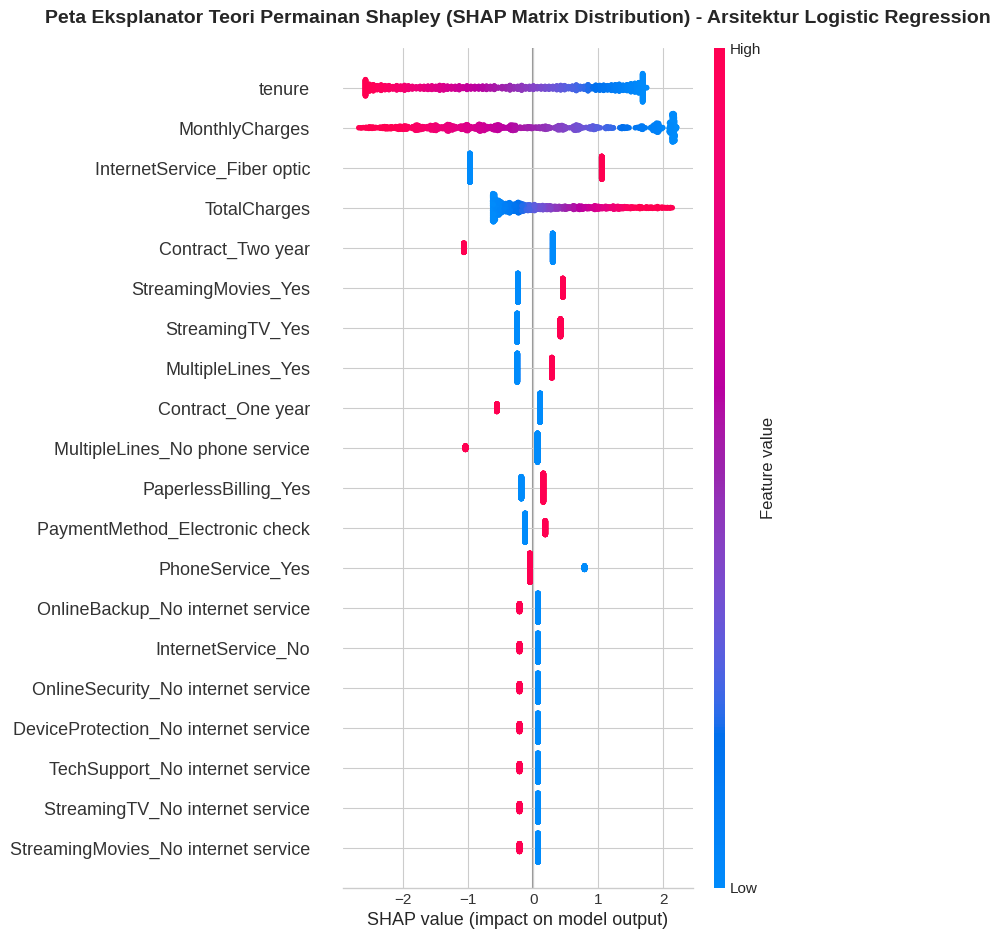

In [78]:
# Pengamanan tipe obyek matriks menuju skalar murni untuk kelancaran perhitungan fungsi SHAP 'float numpy' casting / Type casting mitigation
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

# Inisialisasi unit perakit eksplanasi interaktif dinamis merujuk ke arsitektur fungsional terpasang / Target binding selection
if 'Logistic Regression' in nama_arsitektur_terbaik:
    modul_explainer = shap.LinearExplainer(model_final, X_train_shap)
    kalkulasi_nilai_shap = modul_explainer.shap_values(X_test_shap)
else:
    modul_explainer = shap.TreeExplainer(model_final)
    kalkulasi_nilai_shap = modul_explainer.shap_values(X_test_shap)

# Cetak kerangka plot kerapatan fungsional interpretasi operasional Matplotlib native layouting / Visual rendering sequence
plt.figure(figsize=(10, 8))
shap.summary_plot(kalkulasi_nilai_shap, X_test_shap, plot_type="dot", show=False)
plt.title(f'Peta Eksplanator Teori Permainan Shapley (SHAP Matrix Distribution) - Arsitektur {nama_arsitektur_terbaik}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Berdasarkan peta eksplanator distribusi nilai SHAP pada gambar di atas, arah dan dampak polarisasi dari setiap fitur utama terhadap prediksi *churn* dapat dibedah secara transparan. Berikut adalah beberapa wawasan bisnis (*business insights*) singkat yang berhasil diambil:

* **Dinamika Kontras Tenure dan Beban Bulanan:** Durasi langganan (`tenure`) dan biaya bulanan (`MonthlyCharges`) menjadi penggerak utama dengan arah pengaruh yang berlawanan. Pelanggan baru dengan masa langganan yang rendah (titik-titik biru) berkumpul di area positif sebelah kanan, menandakan tingginya risiko atrisi di awal siklus hidup pelanggan. Sementara itu, tarif bulanan yang tinggi (titik-titik merah) dominan di sisi kanan, mengonfirmasi bahwa harga yang mahal menjadi pemicu langsung yang mendorong pelanggan untuk memutus layanan.

* **Anomali Kerentanan Pengguna Fiber Optic:** Fitur `InternetService_Fiber optic` memperlihatkan sebaran yang sangat tegas, di mana pengguna layanan ini (titik-titik merah) menumpuk di zona dampak positif. Temuan ini memperkuat analisis pada tahapan sebelumnya bahwa segmen premium berbasis serat optik ini sedang mengalami masalah kesesuaian nilai (*price-to-value mismatch*), yang bisa dipicu oleh gangguan teknis jaringan atau paparan promosi kompetitor yang lebih agresif.

* **Efek Pengaman Struktural dari Kontrak Jangka Panjang:** Kebalikan dari layanan internet, fitur komitmen seperti `Contract_Two year` bertindak sebagai pelindung loyalitas. Pelanggan yang terikat kontrak dua tahun (titik-titik merah) bergeser kuat ke sisi kiri (dampak negatif), membuktikan bahwa skema komitmen ini sangat efektif dalam mengunci pangkalan pelanggan dan mereduksi peluang mereka untuk berpindah provider.